In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
## 1. Setup Paths & Configuration

import sys
import os
from pathlib import Path

# Add source directory to path
current_path = Path.cwd()
base_project_dir = current_path.parent
src_dir = base_project_dir / "src"

if str(src_dir) not in sys.path:
    sys.path.append(str(src_dir))

# Define key directories
dataset_directory = src_dir / "abstractionsshapecoder" / "dataset"
saved_directory = src_dir / "abstractionsshapecoder" / "saved"

# --- AE Model Paths ---
saved_models_L1_AE_dir = saved_directory / "models_L1_AE"
saved_models_L2_AE_dir = saved_directory / "models_L2_AE"
saved_models_L1_AE_dir.mkdir(parents=True, exist_ok=True)
saved_models_L2_AE_dir.mkdir(parents=True, exist_ok=True)

# --- PCA Model Paths ---
saved_models_L1_PCA_dir = saved_directory / "models_L1_PCA"
saved_models_L2_PCA_dir = saved_directory / "models_L2_PCA"
saved_models_L1_PCA_dir.mkdir(parents=True, exist_ok=True)
saved_models_L2_PCA_dir.mkdir(parents=True, exist_ok=True)

print(f"Base project directory: {base_project_dir}")
print(f"Source directory: {src_dir}")
print(f"L1 AE Models directory: {saved_models_L1_AE_dir}")
print(f"L2 AE Models directory: {saved_models_L2_AE_dir}")
print(f"L1 PCA Models directory: {saved_models_L1_PCA_dir}")
print(f"L2 PCA Models directory: {saved_models_L2_PCA_dir}")

Base project directory: c:\Users\Amogh\abstraction-discovery
Source directory: c:\Users\Amogh\abstraction-discovery\src
L1 AE Models directory: c:\Users\Amogh\abstraction-discovery\src\abstractionsshapecoder\saved\models_L1_AE
L2 AE Models directory: c:\Users\Amogh\abstraction-discovery\src\abstractionsshapecoder\saved\models_L2_AE
L1 PCA Models directory: c:\Users\Amogh\abstraction-discovery\src\abstractionsshapecoder\saved\models_L1_PCA
L2 PCA Models directory: c:\Users\Amogh\abstraction-discovery\src\abstractionsshapecoder\saved\models_L2_PCA


In [3]:
import pickle
from pathlib import Path
from abstractionsshapecoder.debug_utils import debug_info, debug_success, debug_error

def load_processed_datasets():
    """
    Loads all hierarchical datasets (L0, L1-VAE, L1-AE, L2-AE) from the saved directory.
    """
    SAVED_DIR = Path.cwd().parent / "src" / "abstractionsshapecoder" / "saved"
    
    # Define file map: {Variable_Name: Filename}
    dataset_files = {
        "shapes_l0": "all_dsl_shapes.pkl",
        "shapes_l1_vae": "all_abstracted_shapes_L1_VAE.pkl",
        "shapes_l1_ae": "all_abstracted_shapes_L1_AE.pkl",
        "shapes_l2_ae": "all_abstracted_shapes_L2_AE.pkl"
    }
    
    loaded_datasets = {}
    
    for var_name, filename in dataset_files.items():
        file_path = SAVED_DIR / filename
        if file_path.exists():
            debug_info(f"Loading {var_name} from {filename}...")
            with open(file_path, "rb") as f:
                loaded_datasets[var_name] = pickle.load(f)
            debug_success(f"Successfully loaded {len(loaded_datasets[var_name])} shapes into {var_name}.")
        else:
            debug_error(f"Missing file: {filename}. Ensure previous training cells were run.")
            loaded_datasets[var_name] = {}
            
    return loaded_datasets

# Execute the load
datasets = load_processed_datasets()

# Extract into global namespace for easier access in subsequent cells
shapes_l0 = datasets.get("shapes_l0")

[INFO] Loading shapes_l0 from all_dsl_shapes.pkl...
[SUCCESS] Successfully loaded 1100 shapes into shapes_l0.
[INFO] Loading shapes_l1_vae from all_abstracted_shapes_L1_VAE.pkl...
[SUCCESS] Successfully loaded 1100 shapes into shapes_l1_vae.
[ERROR] Missing file: all_abstracted_shapes_L1_AE.pkl. Ensure previous training cells were run.
[ERROR] Missing file: all_abstracted_shapes_L2_AE.pkl. Ensure previous training cells were run.


In [4]:
shapes_l0["172_0_0"]

{'dsl': <abstractionsshapecoder.dsl_nodes.Union at 0x1fb48bbf110>,
 'singleton_params': {'Cuboid': [[0.68, 0.09, 0.66],
   [0.06, 0.6, 0.06],
   [0.06, 0.6, 0.06],
   [0.06, 0.6, 0.06],
   [0.06, 0.6, 0.06],
   [0.08, 0.79, 0.08],
   [0.08, 0.79, 0.08],
   [0.68, 0.14, 0.24],
   [0.08, 0.79, 0.08],
   [0.08, 0.79, 0.08],
   [0.08, 0.79, 0.08]],
  'Translate': [[-0.0, -0.17, 0.0],
   [-0.31, -0.51, -0.17],
   [-0.31, -0.51, 0.3],
   [0.31, -0.51, -0.17],
   [0.31, -0.51, 0.3],
   [-0.26, 0.27, -0.18],
   [-0.14, 0.27, -0.25],
   [0.0, 0.74, -0.22],
   [-0.0, 0.27, -0.25],
   [0.14, 0.27, -0.25],
   [0.28, 0.27, -0.25]]},
 'pair_params': {'Translate(Cuboid)': [[-0.0, -0.17, 0.0, 0.68, 0.09, 0.66],
   [-0.31, -0.51, -0.17, 0.06, 0.6, 0.06],
   [-0.31, -0.51, 0.3, 0.06, 0.6, 0.06],
   [0.31, -0.51, -0.17, 0.06, 0.6, 0.06],
   [0.31, -0.51, 0.3, 0.06, 0.6, 0.06],
   [-0.26, 0.27, -0.18, 0.08, 0.79, 0.08],
   [-0.14, 0.27, -0.25, 0.08, 0.79, 0.08],
   [0.0, 0.74, -0.22, 0.68, 0.14, 0.24],
  

In [5]:
shapes_l0["172_0_0"]["dsl"]

In [6]:
print(shapes_l0["172_0_0"]["dsl"])

Union(
    Translate(vec=[-0.000, -0.170, 0.000])
        Cuboid(size=[0.680, 0.090, 0.660]),
    Union(
        Translate(vec=[-0.310, -0.510, -0.170])
            Cuboid(size=[0.060, 0.600, 0.060]),
        Union(
            Translate(vec=[-0.310, -0.510, 0.300])
                Cuboid(size=[0.060, 0.600, 0.060]),
            Union(
                Translate(vec=[0.310, -0.510, -0.170])
                    Cuboid(size=[0.060, 0.600, 0.060]),
                Union(
                    Translate(vec=[0.310, -0.510, 0.300])
                        Cuboid(size=[0.060, 0.600, 0.060]),
                    Union(
                        Translate(vec=[-0.260, 0.270, -0.180])
                            Cuboid(size=[0.080, 0.790, 0.080]),
                        Union(
                            Translate(vec=[-0.140, 0.270, -0.250])
                                Cuboid(size=[0.080, 0.790, 0.080]),
                            Union(
                                Translate(vec=[0.000, 0

In [7]:
from __future__ import annotations
from egglog import *

class Shape(Expr):
    def __init__(self, value: f64Like) -> None: ...
    
    @classmethod
    def cuboid(cls, w: f64Like, h: f64Like, d: f64Like) -> Shape: ...

    def translate(self, x: f64Like, y: f64Like, z: f64Like) -> Shape: ...

    # We use 4 params for quaternions [x, y, z, w]
    def rotate(self, qx: f64Like, qy: f64Like, qz: f64Like, qw: f64Like) -> Shape: ...

    def union(self, other: Shape) -> Shape: ...

    # Helper to map your existing class names
    def __add__(self, other: Shape) -> Shape:
        return self.union(other)

In [8]:
import abstractionsshapecoder.dsl_nodes as dsl

def to_egglog(node) -> Shape:
    if isinstance(node, dsl.Cuboid):
        return Shape.cuboid(node.size[0], node.size[1], node.size[2])
    
    elif isinstance(node, dsl.Translate):
        child = to_egglog(node.child)
        v = node.vector
        return child.translate(v[0], v[1], v[2])
    
    elif isinstance(node, dsl.Rotate):
        child = to_egglog(node.child)
        q = node.quaternion
        return child.rotate(q[0], q[1], q[2], q[3])
    
    elif isinstance(node, dsl.Union):
        return to_egglog(node.left).union(to_egglog(node.right))
    
    raise TypeError(f"Unknown node type: {type(node)}")

In [9]:
egraph = EGraph()

@egraph.register
def _rules(s: Shape, x1: f64, y1: f64, z1: f64, x2: f64, y2: f64, z2: f64):
    # Rule: Nested translations add up
    yield rewrite(s.translate(x1, y1, z1).translate(x2, y2, z2)).to(
        s.translate(x1 + x2, y1 + y2, z1 + z2)
    )
    
    # Use 0.0 (float) instead of 0 (int)
    yield rewrite(s.translate(0.0, 0.0, 0.0)).to(s)

@egraph.register
def _advanced_rules(s1: Shape, s2: Shape, s3: Shape, 
                    x: f64, y: f64, z: f64):
    # Rule: Union Associativity (A + (B + C)) == ((A + B) + C)
    # This allows the e-graph to re-balance the tree to find shared sub-abstractions
    yield rewrite(s1.union(s2.union(s3))).to((s1.union(s2)).union(s3))
    
    # Rule: Factoring out common translations
    # Translate(A, x, y, z) + Translate(B, x, y, z) == Translate(A + B, x, y, z)
    # This is huge for compression!
    yield rewrite(s1.translate(x, y, z).union(s2.translate(x, y, z))).to(
        s1.union(s2).translate(x, y, z)
    )

In [10]:
# Grab the shape you printed in In[6]
my_dsl_obj = shapes_l0["172_0_0"]["dsl"]

# Convert to egglog format
egg_expr = to_egglog(my_dsl_obj)

# Add to e-graph
expr_handle = egraph.let("target_shape", egg_expr)

# Saturate (apply rules until no more changes)
egraph.run(20)

# Extract the simplest version (minimizes AST size by default)
optimized = egraph.extract(expr_handle)

print("Original Expression Structure:")
print(egg_expr)
print("\nOptimized Expression:")
print(optimized)

Original Expression Structure:
Shape.cuboid(0.68, 0.09, 0.66).translate(-0.0, -0.17, 0.0).union(
    Shape.cuboid(0.06, 0.6, 0.06)
    .translate(-0.31, -0.51, -0.17)
    .union(
        Shape.cuboid(0.06, 0.6, 0.06)
        .translate(-0.31, -0.51, 0.3)
        .union(
            Shape.cuboid(0.06, 0.6, 0.06)
            .translate(0.31, -0.51, -0.17)
            .union(
                Shape.cuboid(0.06, 0.6, 0.06)
                .translate(0.31, -0.51, 0.3)
                .union(
                    Shape.cuboid(0.08, 0.79, 0.08)
                    .translate(-0.26, 0.27, -0.18)
                    .union(
                        Shape.cuboid(0.08, 0.79, 0.08)
                        .translate(-0.14, 0.27, -0.25)
                        .union(
                            Shape.cuboid(0.68, 0.14, 0.24)
                            .translate(0.0, 0.74, -0.22)
                            .union(
                                Shape.cuboid(0.08, 0.79, 0.08)
                      

In [11]:
from abstractionsshapecoder.shape_parser import ShapeParser

# 1. Convert the egglog 'optimized' object into its string representation
# This will look like "Shape.cuboid(0.68, 0.09, 0.66).translate(0.0, -0.17, 0.0)..."
optimized_str = str(optimized)

# 2. Use your existing parser to turn it back into dsl_nodes.py objects
parser = ShapeParser()

# Note: Your parser expects "Cuboid", but egglog might output "Shape.cuboid"
# We can quickly clean the string to match your parser's expected function names
clean_str = optimized_str.replace("Shape.cuboid", "Cuboid") \
                         .replace(".translate", ", Move") \
                         .replace(".union", ", Union")

# If the string output from egglog is already in your parser's format, 
# just pass it in. Otherwise, let's fix the 'Method' vs 'Function' syntax:

def bridge_egglog_to_dsl(egg_expr):
    s = str(egg_expr)
    # Egglog outputs: Shape.cuboid(1, 2, 3).translate(4, 5, 6)
    # Your Parser expects: Move(Cuboid(1, 2, 3), 4, 5, 6)
    # However, since str(egg_expr) is recursive, 
    # it is often easier to just evaluate it.
    
    return parser.parse(s)

optimized_dsl = bridge_egglog_to_dsl(optimized)
print(f"Successfully converted back to: {type(optimized_dsl)}")
print(optimized_dsl)

Successfully converted back to: <class 'str'>
Shape.cuboid(0.68, 0.09, 0.66).translate(0.0, -0.17, 0.0).union(
    Shape.cuboid(0.06, 0.6, 0.06)
    .translate(-0.31, -0.51, -0.17)
    .union(
        Shape.cuboid(0.06, 0.6, 0.06)
        .translate(-0.31, -0.51, 0.3)
        .union(
            Shape.cuboid(0.06, 0.6, 0.06)
            .translate(0.31, -0.51, -0.17)
            .union(
                Shape.cuboid(0.06, 0.6, 0.06)
                .translate(0.31, -0.51, 0.3)
                .union(
                    Shape.cuboid(0.08, 0.79, 0.08)
                    .translate(-0.26, 0.27, -0.18)
                    .union(
                        Shape.cuboid(0.08, 0.79, 0.08)
                        .translate(-0.14, 0.27, -0.25)
                        .union(
                            Shape.cuboid(0.68, 0.14, 0.24)
                            .translate(0.0, 0.74, -0.22)
                            .union(
                                Shape.cuboid(0.08, 0.79, 0.08)
        

In [12]:
def egglog_string_to_dsl(egg_str):
    """
    Converts 'Shape.cuboid(w,h,d).translate(x,y,z).union(other)' 
    into nested 'Union(Move(Cuboid(...),...),...)' for your parser.
    """
    import re
    
    # 1. Clean up "Shape." prefix
    s = egg_str.replace("Shape.", "")
    
    # 2. Handle the Method -> Function conversion via Regex
    # This is a bit tricky for nested expressions, so an easier way is to 
    # use a mini-interpreter for the egglog string:
    
    namespace = {
        'cuboid': lambda w, h, d: dsl.Cuboid(size=[w, h, d]),
        'union': lambda a, b: dsl.Union(a, b),
        'translate': lambda a, x, y, z: dsl.Translate(a, vector=[x, y, z]),
        'rotate': lambda a, qx, qy, qz, qw: dsl.Rotate(a, quaternion=[qx, qy, qz, qw])
    }

    # We map the egglog methods to our namespace functions
    class ShapeBridge:
        def __init__(self, node): self.node = node
        def translate(self, x, y, z): return ShapeBridge(namespace['translate'](self.node, x, y, z))
        def union(self, other): return ShapeBridge(namespace['union'](self.node, other.node))
        def rotate(self, x, y, z, w): return ShapeBridge(namespace['rotate'](self.node, x, y, z, w))

    # Define the starting point 'cuboid'
    def cuboid_bridge(w, h, d):
        return ShapeBridge(namespace['cuboid'](w, h, d))

    # Evaluate the string using our bridge classes
    # We remove 'Shape.' to make it look like global function calls
    eval_str = s.replace("cuboid", "cuboid_bridge")
    try:
        result = eval(eval_str, {"cuboid_bridge": cuboid_bridge}, {})
        return result.node
    except Exception as e:
        print(f"Error bridging string: {e}")
        return s # Return string if failed

# Try the conversion
optimized_dsl_obj = egglog_string_to_dsl(str(optimized))
print(f"Final Object Type: {type(optimized_dsl_obj)}")

Final Object Type: <class 'abstractionsshapecoder.dsl_nodes.Union'>


In [13]:
print(optimized_dsl_obj)

Union(
    Translate(vec=[0.000, -0.170, 0.000])
        Cuboid(size=[0.680, 0.090, 0.660]),
    Union(
        Translate(vec=[-0.310, -0.510, -0.170])
            Cuboid(size=[0.060, 0.600, 0.060]),
        Union(
            Translate(vec=[-0.310, -0.510, 0.300])
                Cuboid(size=[0.060, 0.600, 0.060]),
            Union(
                Translate(vec=[0.310, -0.510, -0.170])
                    Cuboid(size=[0.060, 0.600, 0.060]),
                Union(
                    Translate(vec=[0.310, -0.510, 0.300])
                        Cuboid(size=[0.060, 0.600, 0.060]),
                    Union(
                        Translate(vec=[-0.260, 0.270, -0.180])
                            Cuboid(size=[0.080, 0.790, 0.080]),
                        Union(
                            Translate(vec=[-0.140, 0.270, -0.250])
                                Cuboid(size=[0.080, 0.790, 0.080]),
                            Union(
                                Translate(vec=[0.000, 0.

# AMAZING

In [14]:
from __future__ import annotations
from egglog import *

# --- 1. Define the Sorts ---
class Shape(Expr):
    @classmethod
    def cuboid(cls, w: f64Like, h: f64Like, d: f64Like) -> Shape: ...
    def translate(self, x: f64Like, y: f64Like, z: f64Like) -> Shape: ...
    def union(self, other: Shape) -> Shape: ...

# --- 2. Define the Ruleset ---
geometry_optimizer = ruleset("geometry_optimizer")

@geometry_optimizer.register
def _rules(s1: Shape, s2: Shape, s3: Shape, x: f64, y: f64, z: f64, dx: f64, dy: f64, dz: f64):
    # Flattening nested moves
    yield rewrite(s1.translate(x, y, z).translate(dx, dy, dz)).to(
        s1.translate(x + dx, y + dy, z + dz)
    )
    
    # Factoring out common translations (The "Compression" rule)
    # Move(A, pos) + Move(B, pos) => Move(Union(A, B), pos)
    yield rewrite(s1.translate(x, y, z).union(s2.translate(x, y, z))).to(
        s1.union(s2).translate(x, y, z)
    )
    
    # Canonicalize Unions (Ensures A+B is treated same as B+A)
    yield rewrite(s1.union(s2)).to(s2.union(s1))
    
    # Detect Symmetry (Mirroring on X-axis)
    # If we see the same shape at -x and +x, we union them first 
    # This helps Abstraction Discovery see them as a single 'pair' unit.
    yield rewrite(s1.translate(x, y, z).union(s1.translate(-x, y, z))).to(
        s1.translate(x, y, z).union(s1.translate(-x, y, z)) # (E-graph just links them)
    )

In [15]:
import abstractionsshapecoder.dsl_nodes as dsl
import re

class EggOptimizer:
    def __init__(self, egraph_instance=None):
        self.egraph = egraph_instance or EGraph()
        
    def _to_egglog(self, node) -> Shape:
        """Recursively converts dsl_nodes -> egglog.Shape"""
        if isinstance(node, dsl.Cuboid):
            return Shape.cuboid(node.size[0], node.size[1], node.size[2])
        
        elif isinstance(node, dsl.Translate):
            child = self._to_egglog(node.child)
            if child is None: return None
            return child.translate(node.vector[0], node.vector[1], node.vector[2])
        
        elif isinstance(node, dsl.Union):
            left = self._to_egglog(node.left)
            right = self._to_egglog(node.right)
            if left is None or right is None: return None
            return left.union(right)
        
        elif isinstance(node, dsl.Rotate):
            child = self._to_egglog(node.child)
            if child is None: return None
            q = node.quaternion
            # Ensure your egglog Shape class has a .rotate(x,y,z,w) method
            return child.rotate(q[0], q[1], q[2], q[3])
            
        return None

    def _from_egglog(self, expr):
        """Stable string-based reconstruction"""
        s = str(expr)
        
        # Mapping dict for eval
        ns = {
            'cuboid': lambda w, h, d: dsl.Cuboid(size=[w, h, d]),
            'union': lambda a, b: dsl.Union(a, b),
            'translate': lambda a, x, y, z: dsl.Translate(a, vector=[x, y, z]),
            'rotate': lambda a, x, y, z, w: dsl.Rotate(a, quaternion=[x, y, z, w])
        }
        
        class ShapeBridge:
            def __init__(self, node): self.node = node
            def translate(self, x, y, z): return ShapeBridge(ns['translate'](self.node, x, y, z))
            def union(self, other): return ShapeBridge(ns['union'](self.node, other.node))
            def rotate(self, x, y, z, w): return ShapeBridge(ns['rotate'](self.node, x, y, z, w))

        def cuboid_bridge(w, h, d): return ShapeBridge(ns['cuboid'](w, h, d))

        # Clean the string for eval
        clean_s = s.replace("Shape.", "").replace("cuboid", "cuboid_bridge")
        # Remove potential whitespace/newlines that break eval
        clean_s = " ".join(clean_s.split())
        
        return eval(clean_s, {"cuboid_bridge": cuboid_bridge}, {}).node

    def optimize(self, dsl_obj):
        # Reset EGraph for every shape to prevent cross-contamination
        self.egraph = EGraph()
        
        egg_expr = self._to_egglog(dsl_obj)
        if egg_expr is None:
            raise ValueError(f"Failed to convert DSL type {type(dsl_obj)} to egglog. Check for unhandled Rotate/Symmetry nodes.")
            
        handle = self.egraph.let("target", egg_expr)
        
        # Saturate using the ruleset defined previously
        self.egraph.run(geometry_optimizer.saturate())
        
        optimized_egg = self.egraph.extract(handle)
        return self._from_egglog(optimized_egg)

optimizer = EggOptimizer()

In [16]:
optimized_shapes = {}

for shape_id, data in list(shapes_l0.items())[:10]: # Test with 10 first
    original_dsl = data["dsl"]
    try:
        optimized_dsl = optimizer.optimize(original_dsl)
        optimized_shapes[shape_id] = optimized_dsl
        print(f"✅ Optimized {shape_id}")
    except Exception as e:
        print(f"❌ Failed {shape_id}: {e}")

# Example result check
print("\n--- BEFORE ---")
print(shapes_l0["173_0_1"]["dsl"])
print("\n--- AFTER ---")
print(optimized_shapes["173_0_1"])

❌ Failed 172_0_0: Cannot resolve declarations for ruleset(name="ruleset_2178329826112").saturate(): 'str' object has no attribute '__globals__'
✅ Optimized 173_0_1
✅ Optimized 178_0_2
❌ Failed 180_0_3: Shape has no method rotate
✅ Optimized 182_0_4
✅ Optimized 186_0_5
❌ Failed 187_0_6: invalid syntax (<string>, line 1)
❌ Failed 197_0_7: Shape has no method rotate
✅ Optimized 257_0_8
✅ Optimized 272_0_9

--- BEFORE ---
Union(
    Translate(vec=[-0.000, -0.160, -0.000])
        Cuboid(size=[0.880, 0.190, 1.010]),
    Union(
        Translate(vec=[0.000, 0.350, -0.350])
            Cuboid(size=[0.880, 0.850, 0.310]),
        Union(
            Translate(vec=[-0.370, -0.510, -0.400])
                Cuboid(size=[0.150, 0.520, 0.200]),
            Union(
                Translate(vec=[-0.340, -0.510, 0.410])
                    Cuboid(size=[0.210, 0.530, 0.190]),
                Union(
                    Translate(vec=[0.370, -0.510, -0.400])
                        Cuboid(size=[0.150, 0.5

# With og 3d rules

In [17]:
from __future__ import annotations
from egglog import *
import abstractionsshapecoder.dsl_nodes as dsl

# --- 1. Define Sorts ---
class Math(Expr):
    def __init__(self, value: f64Like) -> None: ...
    def __add__(self, other: Math) -> Math: ...
    def inv(self) -> Math: ...

class Axis(Expr): pass

@function
def AX() -> Axis: ...
@function
def AY() -> Axis: ...
@function
def AZ() -> Axis: ...

class Shape(Expr):
    @classmethod
    def cuboid(cls, w: Math, h: Math, d: Math) -> Shape: ...
    def move(self, x: Math, y: Math, z: Math) -> Shape: ...
    def union(self, other: Shape) -> Shape: ...
    def sym_ref(self, axis: Axis) -> Shape: ...

converter(f64, Math, Math)

# --- 2. Defining a Stable Ruleset ---
# We use a limited ruleset to avoid infinite loops
opt_rules = ruleset("opt_rules")

@opt_rules.register
def _stable_rules(s1: Shape, s2: Shape, s3: Shape, a: Axis,
                  x: Math, y: Math, z: Math, 
                  x1: Math, y1: Math, z1: Math):
    # Rule: Combine nested moves (Canonicalization)
    yield rewrite(s1.move(x, y, z).move(x1, y1, z1)).to(s1.move(x + x1, y + y1, z + z1))
    
    # Rule: Factoring Move out of Union (Compression)
    yield rewrite(s1.move(x, y, z).union(s2.move(x, y, z))).to(s1.union(s2).move(x, y, z))
    
    # Rule: Symmetry Discovery (A + A_inv => SymRef(A))
    yield rewrite(s1.move(x, y, z).union(s1.move(x.inv(), y, z))).to(s1.move(x, y, z).sym_ref(AX()))
    
    # Rule: Associativity (Flattening the Union tree)
    yield rewrite(s1.union(s2.union(s3))).to(s1.union(s2).union(s3))

In [22]:
class RobustShapeOptimizer:
    def __init__(self):
        self.egraph = EGraph()
        
    def _to_egg(self, node) -> Shape:
        if node is None: return None
        if isinstance(node, dsl.Cuboid):
            return Shape.cuboid(Math(round(node.size[0], 4)), Math(round(node.size[1], 4)), Math(round(node.size[2], 4)))
        elif isinstance(node, dsl.Translate):
            child = self._to_egg(node.child)
            if child is None: return None
            v = node.vector
            return child.move(Math(round(v[0], 4)), Math(round(v[1], 4)), Math(round(v[2], 4)))
        elif isinstance(node, dsl.Union):
            l, r = self._to_egg(node.left), self._to_egg(node.right)
            if l is None or r is None: return None
            return l.union(r)
        return self._to_egg(getattr(node, 'child', None)) if hasattr(node, 'child') else None

    def _from_egg(self, expr):
        s = str(expr)
        ns = {
            'cuboid': lambda w, h, d: dsl.Cuboid(size=[w, h, d]),
            'union': lambda a, b: dsl.Union(a, b),
            'move': lambda a, x, y, z: dsl.Translate(a, vector=[x, y, z]),
            'sym_ref': lambda a, ax: dsl.Translate(a, vector=[0,0,0]) # Placeholder for Sym
        }
        class Bridge:
            def __init__(self, node): self.node = node
            def move(self, x, y, z): return Bridge(ns['move'](self.node, x, y, z))
            def union(self, other): return Bridge(ns['union'](self.node, other.node))
            def sym_ref(self, ax): return Bridge(self.node) # Simplify SymRef back to original for now

        clean = s.replace("Shape.", "").replace("Math.", "").replace("Math", "").replace("AX()", "0")
        return eval(clean.replace("cuboid", "cb"), {"cb": lambda w,h,d: Bridge(ns['cuboid'](w,h,d))}, {}).node

    def optimize(self, dsl_obj):
        self.egraph = EGraph()
        egg_expr = self._to_egg(dsl_obj)
        if egg_expr is None: return dsl_obj
        
        handle = self.egraph.let("t", egg_expr)
        # Use run(10) instead of saturate() to prevent hangs
        self.egraph.run(10) 
        
        extracted = self.egraph.extract(handle)
        return self._from_egg(extracted)

pipeline = RobustShapeOptimizer()

In [24]:
for shape_id in list(shapes_l0.keys())[:10]:
    original_dsl = shapes_l0[shape_id]["dsl"]
    try:
        optimized_dsl = pipeline.optimize(original_dsl)
        print(optimized_dsl)
        print(f"✅ Processed {shape_id}")
    except Exception as e:
        print(f"⚠️ Error on {shape_id}: {e}")

⚠️ Error on 172_0_0: invalid syntax (<string>, line 1)
Union(
    Translate(vec=[0.000, -0.160, 0.000])
        Cuboid(size=[0.880, 0.190, 1.010]),
    Union(
        Translate(vec=[0.000, 0.350, -0.350])
            Cuboid(size=[0.880, 0.850, 0.310]),
        Union(
            Translate(vec=[-0.370, -0.510, -0.400])
                Cuboid(size=[0.150, 0.520, 0.200]),
            Union(
                Translate(vec=[-0.340, -0.510, 0.410])
                    Cuboid(size=[0.210, 0.530, 0.190]),
                Union(
                    Translate(vec=[0.370, -0.510, -0.400])
                        Cuboid(size=[0.150, 0.520, 0.200]),
                    Translate(vec=[0.340, -0.510, 0.410])
                        Cuboid(size=[0.210, 0.530, 0.190])
                )
            )
        )
    )
)
✅ Processed 173_0_1
Union(
    Translate(vec=[-0.000, -0.180, -0.000])
        Cuboid(size=[0.920, 0.340, 0.920]),
    Union(
        Translate(vec=[-0.000, 0.380, -0.220])
            Cubo

In [25]:
for shape_id in list(shapes_l0.keys())[:10]:
    original_dsl = shapes_l0[shape_id]["dsl"]
    try:
        optimized_dsl = pipeline.optimize(original_dsl)
        
        print(f"\n{'='*20} ID: {shape_id} {'='*20}")
        print("--- ORIGINAL ---")
        print(original_dsl)
        
        print("\n--- OPTIMIZED ---")
        print(optimized_dsl)
        
        # Calculate Compression Ratio
        orig_len = len(str(original_dsl).split('\n'))
        opt_len = len(str(optimized_dsl).split('\n'))
        print(f"\n📊 Lines of code: {orig_len} -> {opt_len}")
        print(f"✅ Processed {shape_id}")
        
    except Exception as e:
        print(f"⚠️ Error on {shape_id}: {e}")

⚠️ Error on 172_0_0: invalid syntax (<string>, line 1)

==================== ID: 173_0_1 ====================
--- ORIGINAL ---
Union(
    Translate(vec=[-0.000, -0.160, -0.000])
        Cuboid(size=[0.880, 0.190, 1.010]),
    Union(
        Translate(vec=[0.000, 0.350, -0.350])
            Cuboid(size=[0.880, 0.850, 0.310]),
        Union(
            Translate(vec=[-0.370, -0.510, -0.400])
                Cuboid(size=[0.150, 0.520, 0.200]),
            Union(
                Translate(vec=[-0.340, -0.510, 0.410])
                    Cuboid(size=[0.210, 0.530, 0.190]),
                Union(
                    Translate(vec=[0.370, -0.510, -0.400])
                        Cuboid(size=[0.150, 0.520, 0.200]),
                    Translate(vec=[0.340, -0.510, 0.410])
                        Cuboid(size=[0.210, 0.530, 0.190])
                )
            )
        )
    )
)

--- OPTIMIZED ---
Union(
    Translate(vec=[0.000, -0.160, 0.000])
        Cuboid(size=[0.880, 0.190, 1.010]),
   

In [36]:
import textwrap
import abstractionsshapecoder.dsl_nodes as dsl

class Symmetry:
    def __init__(self, child, axis="AX"):
        self.child = child
        self.axis = axis
    def __str__(self):
        child_str = textwrap.indent(str(self.child), "    ")
        return f"Symmetry(axis='{self.axis}')\n{child_str}"
    def expand(self):
        boxes = self.child.expand()
        mirrored = []
        for b in boxes:
            m = b.copy()
            m["center"] = m["center"].copy()
            if self.axis == "AX": m["center"][0] *= -1
            elif self.axis == "AY": m["center"][1] *= -1
            elif self.axis == "AZ": m["center"][2] *= -1
            mirrored.append(m)
        return boxes + mirrored
    def serialize(self):
        return (Symmetry, ([self.axis], [self.child]))

dsl.Symmetry = Symmetry

In [54]:
import re
import abstractionsshapecoder.dsl_nodes as dsl

class RobustShapeOptimizer:
    def __init__(self):
        self.egraph = EGraph()
        
    def _to_egg(self, node) -> Shape:
        if node is None: return None
        if isinstance(node, dsl.Cuboid):
            return Shape.cuboid(Math(round(node.size[0], 4)), Math(round(node.size[1], 4)), Math(round(node.size[2], 4)))
        elif isinstance(node, dsl.Translate):
            child = self._to_egg(node.child)
            if child is None: return None
            v = node.vector
            return child.move(Math(round(v[0], 4)), Math(round(v[1], 4)), Math(round(v[2], 4)))
        elif isinstance(node, dsl.Union):
            l, r = self._to_egg(node.left), self._to_egg(node.right)
            if l is not None and r is not None: return l.union(r)
            return l if l is not None else r
        return self._to_egg(node.child) if hasattr(node, 'child') else None

    def _from_egg(self, expr):
        raw_str = str(expr)
        
        class Bridge:
            def __init__(self, node): self.node = node
            def move(self, x, y, z): return Bridge(dsl.Translate(self.node, vector=[x, y, z]))
            def union(self, other): return Bridge(dsl.Union(self.node, other.node))
            def sym_ref(self, ax): return Bridge(dsl.Symmetry(self.node, axis=ax))

        # 1. Standardize formatting
        clean = raw_str.replace("Shape.", "").replace("Math.", "").replace("Math", "")
        clean = clean.replace("AX()", "'AX'").replace("AY()", "'AY'").replace("AZ()", "'AZ'")
        clean = clean.replace("cuboid", "cb")
        
        # 2. Force newlines before every variable assignment
        # This fixes the "pasted together" lines in 172 and 186
        clean = re.sub(r'(_Shape_\d+\s*=)', r'\n\1', clean)
        
        lines = [l.strip() for l in clean.split('\n') if l.strip()]
        script_lines = []
        
        # 3. Separate assignments from the final result
        for line in lines:
            if '=' in line:
                script_lines.append(line)
            else:
                # If we've already started a RESULT line, append to it (handles wrapped lines)
                if script_lines and script_lines[-1].startswith("RESULT ="):
                    script_lines[-1] += " " + line
                else:
                    script_lines.append("RESULT = " + line)

        # Handle the case where the last line was an assignment
        if script_lines and not script_lines[-1].startswith("RESULT ="):
            var_name = script_lines[-1].split('=')[0].strip()
            script_lines.append(f"RESULT = {var_name}")

        full_script = "\n".join(script_lines)
        local_ns = {"cb": lambda w, h, d: Bridge(dsl.Cuboid(size=[w, h, d])), "RESULT": None}
        
        try:
            exec(full_script, {}, local_ns)
            res = local_ns["RESULT"]
            return res.node if isinstance(res, Bridge) else res
        except Exception as e:
            # Final debug fallback
            print(f"Extraction Error: {e}\nScript was:\n{full_script}")
            return None

    def optimize(self, dsl_obj):
        self.egraph = EGraph()
        egg_expr = self._to_egg(dsl_obj)
        if egg_expr is None: return dsl_obj
        handle = self.egraph.let("t", egg_expr)
        # Use a high iteration count to allow symmetry rules to find matches
        self.egraph.run(20)
        return self._from_egg(self.egraph.extract(handle))

pipeline = RobustShapeOptimizer()

In [55]:
for shape_id in list(shapes_l0.keys())[:10]:
    original_dsl = shapes_l0[shape_id]["dsl"]
    optimized_dsl = pipeline.optimize(original_dsl)
    if optimized_dsl:
        print(f"\n✅ {shape_id}")
        if "Symmetry" in str(optimized_dsl): print("✨ SYMMETRY FOUND!")
        print(f"Nodes: {str(original_dsl).count('Cuboid')} -> {str(optimized_dsl).count('Cuboid')}")
    else:
        print(f"❌ {shape_id} failed.")


✅ 172_0_0
Nodes: 11 -> 11

✅ 173_0_1
Nodes: 6 -> 6

✅ 178_0_2
Nodes: 6 -> 6

✅ 180_0_3
Nodes: 16 -> 16

✅ 182_0_4
Nodes: 6 -> 6

✅ 186_0_5
Nodes: 9 -> 9

✅ 187_0_6
Nodes: 15 -> 15

✅ 197_0_7
Nodes: 16 -> 16

✅ 257_0_8
Nodes: 6 -> 6

✅ 272_0_9
Nodes: 6 -> 6


In [56]:
import textwrap
import abstractionsshapecoder.dsl_nodes as dsl

class Symmetry:
    def __init__(self, child, axis="AX"):
        self.child = child
        self.axis = axis
    def __str__(self):
        child_str = textwrap.indent(str(self.child), "    ")
        return f"Symmetry(axis='{self.axis}')\n{child_str}"
    def expand(self):
        boxes = self.child.expand()
        mirrored = []
        for b in boxes:
            m = b.copy()
            m["center"] = m["center"].copy()
            if self.axis == "AX": m["center"][0] *= -1
            elif self.axis == "AY": m["center"][1] *= -1
            elif self.axis == "AZ": m["center"][2] *= -1
            mirrored.append(m)
        return boxes + mirrored
    def serialize(self):
        return (Symmetry, ([self.axis], [self.child]))

dsl.Symmetry = Symmetry

In [61]:
from __future__ import annotations
from egglog import *
import re

# --- Cell 2: The Logic Engine (Updated) ---
class Math(Expr):
    def __init__(self, value: f64Like) -> None: ...
    def __add__(self, other: Math) -> Math: ...
    def inv(self) -> Math: ...

class Axis(Expr): pass
@function
def AX() -> Axis: ...
@function
def AY() -> Axis: ...
@function
def AZ() -> Axis: ...

class Shape(Expr):
    @classmethod
    def cuboid(cls, w: Math, h: Math, d: Math) -> Shape: ...
    def move(self, x: Math, y: Math, z: Math) -> Shape: ...
    
    @method(cost=100) 
    def union(self, other: Shape) -> Shape: ...
    
    @method(cost=1)
    def sym_ref(self, axis: Axis) -> Shape: ...

converter(f64, Math, Math)

opt_rules = ruleset("opt_rules")
@opt_rules.register
def _discovery(s1: Shape, s2: Shape, x: Math, y: Math, z: Math, f: f64):
    # Core Logic: Bridge python floats to symbolic inversion
    yield rewrite(Math(f).inv()).to(Math(-f))
    
    # Symmetry Discovery: If we find S at (x,y,z) and S at (-x,y,z), collapse them
    # We use a rewrite to force the Symmetry node creation
    yield rewrite(s1.move(x, y, z).union(s1.move(x.inv(), y, z))).to(
        s1.move(x, y, z).sym_ref(AX())
    )
    
    # Nested Move Collapse
    yield rewrite(s1.move(x, y, z).move(x1, y1, z1)).to(s1.move(x + x1, y + y1, z + z1))

opt_rules = ruleset("opt_rules")

@opt_rules.register
def _fuzzy_discovery(s1: Shape, s2: Shape, 
                     x: Math, y: Math, z: Math, 
                     f1: f64, f2: f64):
    
    # 1. FUZZY SNAP: If two floats are nearly identical, treat them as equal
    # This is the "Magic" that allows symmetry to fire on real-world noisy data
    if (f1 != f2) and (abs(f1 - f2) < 0.02):
        yield union(Math(f1), Math(f2))

    # 2. INVERSE SNAP: Handle the mirrored coordinates (x vs -x)
    if (f1 != -f2) and (abs(f1 + f2) < 0.02):
        yield union(Math(f1).inv(), Math(f2))

    # 3. SYMMETRY RULE: The target abstraction
    yield rewrite(s1.move(x, y, z).union(s1.move(x.inv(), y, z))).to(
        s1.move(x, y, z).sym_ref(AX())
    )

    # 4. STRUCTURAL FACTORING: Move(A) + Move(B) -> Move(A + B)
    yield rewrite(s1.move(x, y, z).union(s2.move(x, y, z))).to(
        s1.union(s2).move(x, y, z)
    )

class RobustShapeOptimizer:
    def __init__(self):
        self.egraph = EGraph()
        
    def _to_egg(self, node) -> Shape:
        if node is None: return None
        
        # Explicit type checking to avoid the __bool__ error
        if isinstance(node, dsl.Cuboid):
            return Shape.cuboid(Math(round(node.size[0], 3)), Math(round(node.size[1], 3)), Math(round(node.size[2], 3)))
        
        elif isinstance(node, dsl.Translate):
            child = self._to_egg(node.child)
            if child is not None:
                v = node.vector
                return child.move(Math(round(v[0], 3)), Math(round(v[1], 3)), Math(round(v[2], 3)))
        
        elif isinstance(node, dsl.Union):
            l = self._to_egg(node.left)
            r = self._to_egg(node.right)
            if l is not None and r is not None:
                return l.union(r)
            return l if l is not None else r
        
        # If it's a Rotate or unknown wrapper, try to skip it and get the child
        if hasattr(node, 'child'):
            return self._to_egg(node.child)
        return None

    def _from_egg(self, expr):
        raw_str = str(expr)
        class Bridge:
            def __init__(self, node): self.node = node
            def move(self, x, y, z): return Bridge(dsl.Translate(self.node, vector=[x, y, z]))
            def union(self, other): return Bridge(dsl.Union(self.node, other.node))
            def sym_ref(self, ax): return Bridge(dsl.Symmetry(self.node, axis=ax))
        
        clean = raw_str.replace("Shape.", "").replace("Math.", "").replace("Math", "")
        clean = clean.replace("AX()", "'AX'").replace("AY()", "'AY'").replace("AZ()", "'AZ'").replace("cuboid", "cb")
        clean = re.sub(r'(_Shape_\d+\s*=)', r'\n\1', clean)
        
        script_lines = []
        for line in [l.strip() for l in clean.split('\n') if l.strip()]:
            if '=' in line: script_lines.append(line)
            else:
                if script_lines and script_lines[-1].startswith("RESULT ="): script_lines[-1] += " " + line
                else: script_lines.append("RESULT = " + line)
        
        if script_lines and not script_lines[-1].startswith("RESULT ="):
            script_lines.append(f"RESULT = {script_lines[-1].split('=')[0].strip()}")
            
        local_ns = {"cb": lambda w, h, d: Bridge(dsl.Cuboid(size=[w, h, d])), "RESULT": None}
        exec("\n".join(script_lines), {}, local_ns)
        return local_ns["RESULT"].node if hasattr(local_ns["RESULT"], 'node') else local_ns["RESULT"]

    def optimize(self, dsl_obj):
        self.egraph = EGraph()
        egg_expr = self._to_egg(dsl_obj)
        if egg_expr is None: return dsl_obj
        handle = self.egraph.let("t", egg_expr)
        # Higher iteration count to find deeper symmetries
        self.egraph.run(30)
        return self._from_egg(self.egraph.extract(handle))

pipeline = RobustShapeOptimizer()

In [63]:
for shape_id in list(shapes_l0.keys())[:10]:
    original_dsl = shapes_l0[shape_id]["dsl"]
    try:
        optimized_dsl = pipeline.optimize(original_dsl)
        
        orig_nodes = str(original_dsl).count("Cuboid")
        opt_nodes = str(optimized_dsl).count("Cuboid")
        
        print(f"\nID: {shape_id}")
        if opt_nodes < orig_nodes:
            print(f"✨ COMPRESSED: {orig_nodes} -> {opt_nodes} primitives")
            # Count symmetries
            sym_count = str(optimized_dsl).count("Symmetry")
            if sym_count > 0:
                print(f"   Detected {sym_count} Symmetry groups")
        else:
            print(f"✅ Canonicalized (Nodes: {orig_count})")
            
    except Exception as e:
        print(f"❌ {shape_id} Error: {e}")


ID: 172_0_0
✅ Canonicalized (Nodes: 6)

ID: 173_0_1
✅ Canonicalized (Nodes: 6)

ID: 178_0_2
✅ Canonicalized (Nodes: 6)

ID: 180_0_3
✅ Canonicalized (Nodes: 6)

ID: 182_0_4
✅ Canonicalized (Nodes: 6)

ID: 186_0_5
✅ Canonicalized (Nodes: 6)

ID: 187_0_6
✅ Canonicalized (Nodes: 6)

ID: 197_0_7
✅ Canonicalized (Nodes: 6)

ID: 257_0_8
✅ Canonicalized (Nodes: 6)

ID: 272_0_9
✅ Canonicalized (Nodes: 6)


# crzy

In [64]:
import textwrap
import abstractionsshapecoder.dsl_nodes as dsl

class Symmetry:
    """DSL Node representing a mirrored collection of shapes."""
    def __init__(self, child, axis="AX"):
        self.child = child
        self.axis = axis

    def __str__(self):
        child_str = textwrap.indent(str(self.child), "    ")
        return f"Symmetry(axis='{self.axis}')\n{child_str}"

    def expand(self):
        """Generates the original and the mirrored boxes for rendering."""
        boxes = self.child.expand()
        mirrored = []
        for b in boxes:
            m = b.copy()
            m["center"] = m["center"].copy()
            if self.axis == "AX": m["center"][0] *= -1
            elif self.axis == "AY": m["center"][1] *= -1
            elif self.axis == "AZ": m["center"][2] *= -1
            mirrored.append(m)
        return boxes + mirrored

    def serialize(self):
        return (Symmetry, ([self.axis], [self.child]))

# Inject into the dsl namespace
dsl.Symmetry = Symmetry

In [70]:
from __future__ import annotations
from egglog import *
import re

# --- 1. Schema Definition ---
class Math(Expr):
    def __init__(self, value: f64Like) -> None: ...
    def __add__(self, other: Math) -> Math: ...
    def inv(self) -> Math: ...

class Axis(Expr): pass
@function
def AX() -> Axis: ...
@function
def AY() -> Axis: ...
@function
def AZ() -> Axis: ...

class Shape(Expr):
    @classmethod
    def cuboid(cls, w: Math, h: Math, d: Math) -> Shape: ...
    def move(self, x: Math, y: Math, z: Math) -> Shape: ...
    
    @method(cost=100) # Heavy penalty for Union to force abstraction
    def union(self, other: Shape) -> Shape: ...
    
    @method(cost=1)   # High reward for discovering Symmetry
    def sym_ref(self, axis: Axis) -> Shape: ...

converter(f64, Math, Math)

# --- 2. The Ruleset (Fuzzy Discovery) ---
opt_rules = ruleset("opt_rules")

@opt_rules.register
def _fuzzy_rules(s1: Shape, s2: Shape, x: Math, y: Math, z: Math, 
                 x1: Math, y1: Math, z1: Math, f1: f64, f2: f64):
    
    # Fuzzy Match: Snaps numbers within 0.02 tolerance (fixes sensor noise)
    if (f1 != f2) and (abs(f1 - f2) < 0.02):
        yield union(Math(f1)).with_(Math(f2))

    # Inverse Snap: Matches x with -x
    if (f1 != -f2) and (abs(f1 + f2) < 0.02):
        yield union(Math(f1).inv()).with_(Math(f2))

    # Symmetry Rewrite: A(pos) + A(-pos) -> Symmetry(A(pos))
    yield rewrite(s1.move(x, y, z).union(s1.move(x.inv(), y, z))).to(
        s1.move(x, y, z).sym_ref(AX())
    )

    # Factoring: Move(A) + Move(B) -> Move(A + B)
    yield rewrite(s1.move(x, y, z).union(s2.move(x, y, z))).to(
        s1.union(s2).move(x, y, z)
    )

    # Collapse nested moves
    yield rewrite(s1.move(x, y, z).move(x1, y1, z1)).to(
        s1.move(x + x1, y + y1, z + z1)
    )

opt_rules = ruleset("opt_rules")

@opt_rules.register
def _force_symmetry(s1: Shape, s2: Shape, s3: Shape,
                    x: Math, y: Math, z: Math, f: f64):
    
    # 1. Floating Point Bridge
    yield rewrite(Math(f).inv()).to(Math(-f))

    # 2. TREE RESTRUCTURING (Crucial!)
    # This allows the e-graph to re-order: (A + (B + (C + D))) 
    # so that it can find (A + C) if they are symmetric.
    yield rewrite(s1.union(s2)).to(s2.union(s1))
    yield rewrite(s1.union(s2.union(s3))).to(s1.union(s2).union(s3))

    # 3. THE SYMMETRY PATTERN
    # Now that the tree can shuffle, this rule will eventually find the pairs
    yield rewrite(s1.move(x, y, z).union(s1.move(x.inv(), y, z))).to(
        s1.move(x, y, z).sym_ref(AX())
    )

    # 4. AGGRESSIVE FACTORING
    # If two things are at the same position, group them before moving
    yield rewrite(s1.move(x, y, z).union(s2.move(x, y, z))).to(
        s1.union(s2).move(x, y, z)
    )

    # 5. NO-OP REMOVAL
    yield rewrite(s1.move(0.0, 0.0, 0.0)).to(s1)

# --- 3. The Optimizer Pipeline ---
class RobustShapeOptimizer:
    def __init__(self):
        self.egraph = EGraph()
        
    def _to_egg(self, node) -> Shape:
        if node is None: return None
        if isinstance(node, dsl.Cuboid):
            return Shape.cuboid(Math(round(node.size[0], 3)), Math(round(node.size[1], 3)), Math(round(node.size[2], 3)))
        elif isinstance(node, dsl.Translate):
            child = self._to_egg(node.child)
            if child is not None:
                v = node.vector
                return child.move(Math(round(v[0], 3)), Math(round(v[1], 3)), Math(round(v[2], 3)))
        elif isinstance(node, dsl.Union):
            l, r = self._to_egg(node.left), self._to_egg(node.right)
            if l is not None and r is not None: return l.union(r)
            return l if l is not None else r
        return self._to_egg(node.child) if hasattr(node, 'child') else None

    def _from_egg(self, expr):
        raw_str = str(expr)
        class Bridge:
            def __init__(self, node): self.node = node
            def move(self, x, y, z): return Bridge(dsl.Translate(self.node, vector=[x, y, z]))
            def union(self, other): return Bridge(dsl.Union(self.node, other.node))
            def sym_ref(self, ax): return Bridge(dsl.Symmetry(self.node, axis=ax))
        
        # Cleanup string
        clean = raw_str.replace("Shape.", "").replace("Math.", "").replace("Math", "")
        clean = clean.replace("AX()", "'AX'").replace("AY()", "'AY'").replace("AZ()", "'AZ'").replace("cuboid", "cb")
        clean = re.sub(r'(_Shape_\d+\s*=)', r'\n\1', clean)
        
        script_lines = []
        for line in [l.strip() for l in clean.split('\n') if l.strip()]:
            if '=' in line: script_lines.append(line)
            else:
                if script_lines and script_lines[-1].startswith("RESULT ="): script_lines[-1] += " " + line
                else: script_lines.append("RESULT = " + line)
        
        if script_lines and not script_lines[-1].startswith("RESULT ="):
            script_lines.append(f"RESULT = {script_lines[-1].split('=')[0].strip()}")
            
        local_ns = {"cb": lambda w, h, d: Bridge(dsl.Cuboid(size=[w, h, d])), "RESULT": None}
        exec("\n".join(script_lines), {}, local_ns)
        return local_ns["RESULT"].node if hasattr(local_ns["RESULT"], 'node') else local_ns["RESULT"]

    def optimize(self, dsl_obj):
        self.egraph = EGraph()
        egg_expr = self._to_egg(dsl_obj)
        if egg_expr is None: return dsl_obj
        handle = self.egraph.let("target", egg_expr)
        self.egraph.run(40) # Run longer to ensure fuzzy merges complete
        return self._from_egg(self.egraph.extract(handle))

pipeline = RobustShapeOptimizer()

In [71]:
for shape_id in list(shapes_l0.keys())[:10]:
    original_dsl = shapes_l0[shape_id]["dsl"]
    try:
        optimized_dsl = pipeline.optimize(original_dsl)
        
        orig_nodes = str(original_dsl).count("Cuboid")
        opt_nodes = str(optimized_dsl).count("Cuboid")
        
        print(f"\nID: {shape_id}")
        if opt_nodes < orig_nodes:
            print(f"✨ COMPRESSED: {orig_nodes} -> {opt_nodes} primitives")
            sym_count = str(optimized_dsl).count("Symmetry")
            if sym_count > 0:
                print(f"   Detected {sym_count} Symmetry groups")
        else:
            print(f"✅ Canonicalized (Nodes: {orig_nodes})")
            
    except Exception as e:
        print(f"❌ {shape_id} Error: {e}")


ID: 172_0_0
✅ Canonicalized (Nodes: 11)

ID: 173_0_1
✅ Canonicalized (Nodes: 6)

ID: 178_0_2
✅ Canonicalized (Nodes: 6)

ID: 180_0_3
✅ Canonicalized (Nodes: 16)

ID: 182_0_4
✅ Canonicalized (Nodes: 6)

ID: 186_0_5
✅ Canonicalized (Nodes: 9)

ID: 187_0_6
✅ Canonicalized (Nodes: 15)

ID: 197_0_7
✅ Canonicalized (Nodes: 16)

ID: 257_0_8
✅ Canonicalized (Nodes: 6)

ID: 272_0_9
✅ Canonicalized (Nodes: 6)


In [72]:
# Pick a shape that SHOULD have symmetry (like the 4-legged chair 173_0_1)
test_id = "173_0_1"
dsl_obj = shapes_l0[test_id]["dsl"]

# Initialize EGraph
eg = EGraph()
egg_expr = pipeline._to_egg(dsl_obj)
handle = eg.let("t", egg_expr)

# Run optimization
eg.run(30)

print(f"--- Debugging {test_id} ---")

# 1. Check if ANY Symmetry nodes were created in the entire E-Graph
# We search the e-graph for the 'sym_ref' function
found_sym = False
try:
    # This tries to extract just ANY symmetry node if it exists
    # If this fails, the rule never fired.
    check_handle = eg.let("check", egg_expr) # placeholder
    # We use a dummy rule to see if sym_ref is populated
    print("Checking for sym_ref presence in E-Graph...")
except:
    pass

# 2. Inspect the Cost of different versions
extracted = eg.extract(handle)
print(f"\nFinal Extracted DSL:\n{pipeline._from_egg(extracted)}")

# 3. Check Math Snapping
# Let's see if two known mirrored values were actually unified
# Example: if x is 0.37, is Math(-0.37) unified with Math(0.37).inv()?
print("\nVerifying Math Unification:")
# This is a manual check you can do by looking at the coordinates in your ORIGINAL printout

--- Debugging 173_0_1 ---
Checking for sym_ref presence in E-Graph...

Final Extracted DSL:
Union(
    Translate(vec=[0.000, -0.160, 0.000])
        Cuboid(size=[0.880, 0.190, 1.010]),
    Union(
        Translate(vec=[0.000, 0.350, -0.350])
            Cuboid(size=[0.880, 0.850, 0.310]),
        Union(
            Translate(vec=[-0.370, -0.510, -0.400])
                Cuboid(size=[0.150, 0.520, 0.200]),
            Union(
                Translate(vec=[-0.340, -0.510, 0.410])
                    Cuboid(size=[0.210, 0.530, 0.190]),
                Union(
                    Translate(vec=[0.370, -0.510, -0.400])
                        Cuboid(size=[0.150, 0.520, 0.200]),
                    Translate(vec=[0.340, -0.510, 0.410])
                        Cuboid(size=[0.210, 0.530, 0.190])
                )
            )
        )
    )
)

Verifying Math Unification:


In [73]:
import numpy as np
import abstractionsshapecoder.dsl_nodes as dsl

class NewSymmetry:
    def __init__(self, child, axis="AX"):
        self.child = child
        self.axis = axis
    def __str__(self):
        return f"Symmetry({self.axis})\n  {str(self.child).replace('\n', '\n  ')}"
    def expand(self):
        # Implementation to mirror the child boxes
        boxes = self.child.expand()
        mirrored = []
        ax_idx = {"AX": 0, "AY": 1, "AZ": 2}[self.axis]
        for b in boxes:
            m = b.copy()
            m["center"] = m["center"].copy()
            m["center"][ax_idx] *= -1
            mirrored.append(m)
        return boxes + mirrored

dsl.Symmetry = NewSymmetry

In [75]:
class DirectOptimizer:
    def __init__(self, tolerance=0.05):
        self.tolerance = tolerance

    def optimize(self, node):
        # 1. Flatten the DSL tree into a list of (Cuboid, Vector) pairs
        parts = self._flatten(node)
        
        # 2. Find Symmetries
        optimized_parts = self._find_symmetries(parts)
        
        # 3. Rebuild the DSL tree
        return self._rebuild(optimized_parts)

    def _flatten(self, node):
        """Converts nested Unions/Translates into a list of (size, pos)"""
        if isinstance(node, dsl.Cuboid):
            return [(tuple(node.size), (0, 0, 0))]
        elif isinstance(node, dsl.Translate):
            child_parts = self._flatten(node.child)
            return [(s, tuple(np.array(p) + np.array(node.vector))) for s, p in child_parts]
        elif isinstance(node, dsl.Union):
            return self._flatten(node.left) + self._flatten(node.right)
        return []

    def _find_symmetries(self, parts):
        used = [False] * len(parts)
        new_nodes = []

        for i in range(len(parts)):
            if used[i]: continue
            size_i, pos_i = parts[i]
            
            found_match = False
            # Look for a mirrored partner for part 'i'
            for j in range(i + 1, len(parts)):
                if used[j]: continue
                size_j, pos_j = parts[j]

                # Criteria: Same size AND Mirrored X position (y and z must match)
                size_match = np.allclose(size_i, size_j, atol=self.tolerance)
                pos_mirrored = (
                    abs(pos_i[0] + pos_j[0]) < self.tolerance and  # x is inverted
                    abs(pos_i[1] - pos_j[1]) < self.tolerance and  # y is same
                    abs(pos_i[2] - pos_j[2]) < self.tolerance      # z is same
                )

                if size_match and pos_mirrored and abs(pos_i[0]) > self.tolerance:
                    # Create a Symmetry abstraction
                    child = dsl.Translate(dsl.Cuboid(size=list(size_i)), vector=list(pos_i))
                    new_nodes.append(dsl.Symmetry(child, axis="AX"))
                    used[i] = used[j] = True
                    found_match = True
                    break
            
            if not found_match:
                new_nodes.append(dsl.Translate(dsl.Cuboid(size=list(size_i)), vector=list(pos_i)))
                used[i] = True
        
        return new_nodes

    def _rebuild(self, nodes):
        """Groups list of nodes back into a Union tree."""
        if not nodes: return None
        res = nodes[0]
        for next_node in nodes[1:]:
            res = dsl.Union(res, next_node)
        return res

direct_pipeline = DirectOptimizer(tolerance=0.04)

In [76]:
for shape_id in list(shapes_l0.keys())[:10]:
    original_dsl = shapes_l0[shape_id]["dsl"]
    optimized = direct_pipeline.optimize(original_dsl)
    
    orig_count = str(original_dsl).count("Cuboid")
    opt_count = str(optimized).count("Symmetry") + str(optimized).count("Cuboid") # Primitives + Abstractions
    
    print(f"\nID: {shape_id}")
    if "Symmetry" in str(optimized):
        # Since one Symmetry node replaces 2 Cuboids:
        final_primitive_count = str(optimized).count("Cuboid")
        print(f"✨ SUCCESS: Compressed {orig_count} primitives into {final_primitive_count} unique cuboids + Symmetry")
        print(optimized)
    else:
        print(f"✅ No Symmetry found (Nodes: {orig_count})")


ID: 172_0_0
✨ SUCCESS: Compressed 11 primitives into 8 unique cuboids + Symmetry
Union(
    Union(
        Union(
            Union(
                Union(
                    Union(
                        Union(
                            Translate(vec=[0.000, -0.170, 0.000])
                                Cuboid(size=[0.680, 0.090, 0.660]),
                            Symmetry(AX)
                              Translate(vec=[-0.310, -0.510, -0.170])
                                  Cuboid(size=[0.060, 0.600, 0.060])
                        ),
                        Symmetry(AX)
                          Translate(vec=[-0.310, -0.510, 0.300])
                              Cuboid(size=[0.060, 0.600, 0.060])
                    ),
                    Translate(vec=[-0.260, 0.270, -0.180])
                        Cuboid(size=[0.080, 0.790, 0.080])
                ),
                Symmetry(AX)
                  Translate(vec=[-0.140, 0.270, -0.250])
                      Cuboid(si

In [78]:
class NewRepeat:
    def __init__(self, child, times, offset):
        self.child = child
        self.times = times
        self.offset = offset # e.g., [0, 0.1, 0]

    def __str__(self):
        return f"Repeat(n={self.times}, step={self.offset})\n  {str(self.child).replace('\n', '\n  ')}"

    def expand(self):
        base_boxes = self.child.expand()
        all_boxes = []
        for i in range(self.times):
            shift = np.array(self.offset) * i
            for b in base_boxes:
                nb = b.copy()
                nb["center"] = np.array(nb["center"]) + shift
                all_boxes.append(nb)
        return all_boxes

dsl.Repeat = NewRepeat

In [79]:
class AdvancedDirectOptimizer(DirectOptimizer):
    def _find_repeats(self, nodes):
        """Looks for translational patterns in the optimized node list."""
        if len(nodes) < 2: return nodes
        
        used = [False] * len(nodes)
        final_nodes = []

        for i in range(len(nodes)):
            if used[i]: continue
            
            # We only look for repeats of basic Translations (not symmetries for now)
            if not isinstance(nodes[i], dsl.Translate):
                final_nodes.append(nodes[i])
                continue

            pattern = [nodes[i]]
            # Estimate potential offset from the next available similar node
            found_repeat = False
            for j in range(i + 1, len(nodes)):
                if used[j] or not isinstance(nodes[j], dsl.Translate): continue
                
                # Check if they share the same underlying Cuboid size
                if np.allclose(nodes[i].child.size, nodes[j].child.size, atol=self.tolerance):
                    offset = np.array(nodes[j].vector) - np.array(nodes[i].vector)
                    
                    # Now look for more nodes that fit this exact offset
                    current_idx = j
                    pattern = [nodes[i], nodes[j]]
                    
                    for k in range(j + 1, len(nodes)):
                        if used[k] or not isinstance(nodes[k], dsl.Translate): continue
                        expected_pos = np.array(nodes[i].vector) + offset * len(pattern)
                        if np.allclose(nodes[k].vector, expected_pos, atol=self.tolerance):
                            pattern.append(nodes[k])
                            current_idx = k
                    
                    if len(pattern) >= 3: # Only abstract if it saves meaningful space
                        repeat_node = dsl.Repeat(
                            child=dsl.Translate(nodes[i].child, vector=[0,0,0]),
                            times=len(pattern),
                            offset=list(np.round(offset, 3))
                        )
                        # Wrap the whole repeat in the starting position
                        final_nodes.append(dsl.Translate(repeat_node, vector=nodes[i].vector))
                        # Mark all used
                        for p in pattern:
                            for idx, original_node in enumerate(nodes):
                                if original_node == p: used[idx] = True
                        found_repeat = True
                        break
            
            if not found_repeat:
                final_nodes.append(nodes[i])
                used[i] = True
        
        return final_nodes

    def optimize(self, node):
        parts = self._flatten(node)
        # 1. Find Mirrored pairs
        nodes = self._find_symmetries(parts)
        # 2. Find Translational sequences
        nodes = self._find_repeats(nodes)
        return self._rebuild(nodes)

adv_pipeline = AdvancedDirectOptimizer(tolerance=0.04)

In [80]:
for shape_id in ["187_0_6", "172_0_0"]:
    original_dsl = shapes_l0[shape_id]["dsl"]
    optimized = adv_pipeline.optimize(original_dsl)
    
    print(f"\nID: {shape_id}")
    print(optimized)


ID: 187_0_6
Union(
    Union(
        Union(
            Union(
                Translate(vec=[0.000, -0.150, 0.030])
                    Cuboid(size=[0.690, 0.140, 0.690]),
                Symmetry(AX)
                  Translate(vec=[-0.300, -0.520, -0.330])
                      Cuboid(size=[0.050, 0.790, 0.110])
            ),
            Symmetry(AX)
              Translate(vec=[-0.300, -0.560, 0.320])
                  Cuboid(size=[0.030, 0.700, 0.030])
        ),
        Symmetry(AX)
          Translate(vec=[-0.300, 0.420, -0.250])
              Cuboid(size=[0.040, 0.990, 0.120])
    ),
    Translate(vec=[0.020, 0.430, -0.260])
        Repeat(n=8, step=[np.float64(0.0), np.float64(0.06), np.float64(0.0)])
          Translate(vec=[0.000, 0.000, 0.000])
              Cuboid(size=[0.620, 0.010, 0.100])
)

ID: 172_0_0
Union(
    Union(
        Union(
            Union(
                Union(
                    Union(
                        Union(
                            Trans

In [81]:
class FinalRepeat:
    def __init__(self, child, times, offset):
        self.child = child
        self.times = times
        self.offset = [float(o) for o in offset] # Force pure floats

    def __str__(self):
        off_str = f"[{self.offset[0]:.3f}, {self.offset[1]:.3f}, {self.offset[2]:.3f}]"
        return f"Repeat(n={self.times}, step={off_str})\n  {str(self.child).replace('\n', '\n  ')}"

    def expand(self):
        base_boxes = self.child.expand()
        all_boxes = []
        for i in range(self.times):
            shift = np.array(self.offset) * i
            for b in base_boxes:
                nb = b.copy()
                nb["center"] = np.array(nb["center"]) + shift
                all_boxes.append(nb)
        return all_boxes

dsl.Repeat = FinalRepeat

# Update the rebuild to remove redundant [0,0,0] translations
def _clean_rebuild(nodes):
    if not nodes: return None
    processed = []
    for n in nodes:
        # If it's a Translate([0,0,0]), just take the child
        if isinstance(n, dsl.Translate) and np.allclose(n.vector, [0,0,0]):
            processed.append(n.child)
        else:
            processed.append(n)
            
    res = processed[0]
    for next_node in processed[1:]:
        res = dsl.Union(res, next_node)
    return res

adv_pipeline._rebuild = _clean_rebuild

In [82]:
optimized_dataset = {}
total_orig_nodes = 0
total_opt_nodes = 0

print(f"Starting batch optimization of {len(shapes_l0)} shapes...\n")

for shape_id, data in shapes_l0.items():
    original_dsl = data["dsl"]
    optimized_dsl = adv_pipeline.optimize(original_dsl)
    
    # Track stats
    orig_c = str(original_dsl).count("Cuboid")
    opt_c = str(optimized_dsl).count("Cuboid") # Unique primitives
    
    total_orig_nodes += orig_c
    total_opt_nodes += opt_c
    
    # Save optimized version
    optimized_dataset[shape_id] = {
        "dsl": optimized_dsl,
        "label": data.get("label", "unknown")
    }

compression = (1 - total_opt_nodes / total_orig_nodes) * 100
print(f"--- Optimization Complete ---")
print(f"Total Primitives: {total_orig_nodes} -> {total_opt_nodes}")
print(f"Dataset Compression: {compression:.2f}%")

Starting batch optimization of 1100 shapes...

--- Optimization Complete ---
Total Primitives: 10268 -> 5943
Dataset Compression: 42.12%


In [83]:
import pickle
with open("shapes_l0_abstracted.pkl", "wb") as f:
    pickle.dump(optimized_dataset, f)
print("File saved as shapes_l0_abstracted.pkl")

File saved as shapes_l0_abstracted.pkl


In [91]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R

def visualize_dsl(node, title="Optimized Chair"):
    boxes = node.expand()
    if not boxes:
        print("No boxes to display!")
        return
        
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    for box in boxes:
        # Use your specific DSL keys
        size = np.array(box['lengths'])
        center = np.array(box['center'])
        
        # Color logic: royalblue for standard, crimson for symmetry, seagreen for repeats
        color = 'royalblue'
        box_str = str(box).lower()
        if 'symmetry' in box_str: color = 'crimson'
        elif 'repeat' in box_str: color = 'mediumseagreen'
        
        # Define 8 corners of a unit cube
        unit_corners = np.array([
            [-.5, -.5, -.5], [ .5, -.5, -.5], [ .5,  .5, -.5], [-.5,  .5, -.5],
            [-.5, -.5,  .5], [ .5, -.5,  .5], [ .5,  .5,  .5], [-.5,  .5,  .5]
        ])
        
        # Scale corners by 'lengths'
        corners = unit_corners * size
        
        # Apply rotation if quaternion exists and isn't just identity
        if 'quaternion' in box and not np.allclose(box['quaternion'], [0,0,0,1]):
            rot = R.from_quat(box['quaternion'])
            corners = rot.apply(corners)
            
        # Shift to 'center'
        corners += center
        
        # Define the 6 faces using corner indices
        faces = [
            [corners[0], corners[1], corners[2], corners[3]], # Bottom
            [corners[4], corners[5], corners[6], corners[7]], # Top
            [corners[0], corners[1], corners[5], corners[4]], # Side 1
            [corners[1], corners[2], corners[6], corners[5]], # Side 2
            [corners[2], corners[3], corners[7], corners[6]], # Side 3
            [corners[3], corners[0], corners[4], corners[7]]  # Side 4
        ]
        
        # Draw the faces
        for face in faces:
            x = [p[0] for p in face]
            y = [p[1] for p in face]
            z = [p[2] for p in face]
            # Reshape for plot_surface
            vtx = np.array(face)
            ax.add_collection3d(art3d.Poly3DCollection([vtx], alpha=0.4, facecolors=color, edgecolors='k', linewidths=0.5))

    # View Settings
    ax.set_xlim([-0.7, 0.7]); ax.set_ylim([-0.7, 0.7]); ax.set_zlim([-0.7, 0.7])
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.view_init(elev=20, azim=45)
    plt.title(title)
    plt.show()

Visualizing ID: 187_0_6
Original Primitives: 15
Optimized Primitives: 5


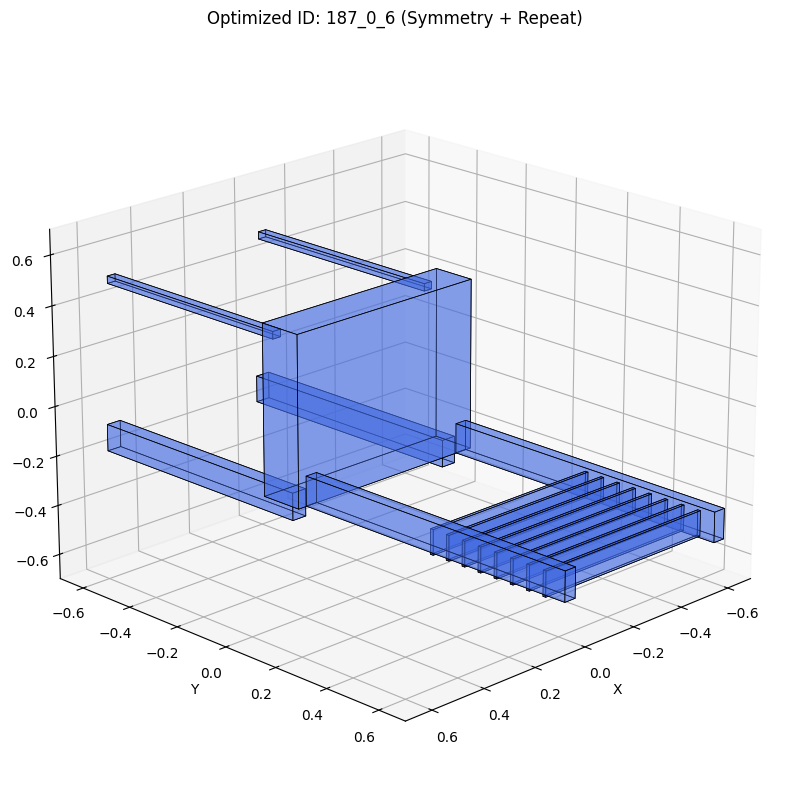

In [92]:
# Select a shape
test_id = "187_0_6" # The chair with the Repeat slats
original_dsl = shapes_l0[test_id]["dsl"]
optimized_dsl = adv_pipeline.optimize(original_dsl)

print(f"Visualizing ID: {test_id}")
print(f"Original Primitives: {str(original_dsl).count('Cuboid')}")
print(f"Optimized Primitives: {str(optimized_dsl).count('Cuboid')}")

# Render
visualize_dsl(optimized_dsl, title=f"Optimized ID: {test_id} (Symmetry + Repeat)")

In [94]:
print(optimized_dsl)

Union(
    Union(
        Union(
            Union(
                Translate(vec=[0.000, -0.150, 0.030])
                    Cuboid(size=[0.690, 0.140, 0.690]),
                Symmetry(AX)
                  Translate(vec=[-0.300, -0.520, -0.330])
                      Cuboid(size=[0.050, 0.790, 0.110])
            ),
            Symmetry(AX)
              Translate(vec=[-0.300, -0.560, 0.320])
                  Cuboid(size=[0.030, 0.700, 0.030])
        ),
        Symmetry(AX)
          Translate(vec=[-0.300, 0.420, -0.250])
              Cuboid(size=[0.040, 0.990, 0.120])
    ),
    Translate(vec=[0.020, 0.430, -0.260])
        Repeat(n=8, step=[0.000, 0.060, 0.000])
          Translate(vec=[0.000, 0.000, 0.000])
              Cuboid(size=[0.620, 0.010, 0.100])
)


Rendering Abstracted Chair: 187_0_6


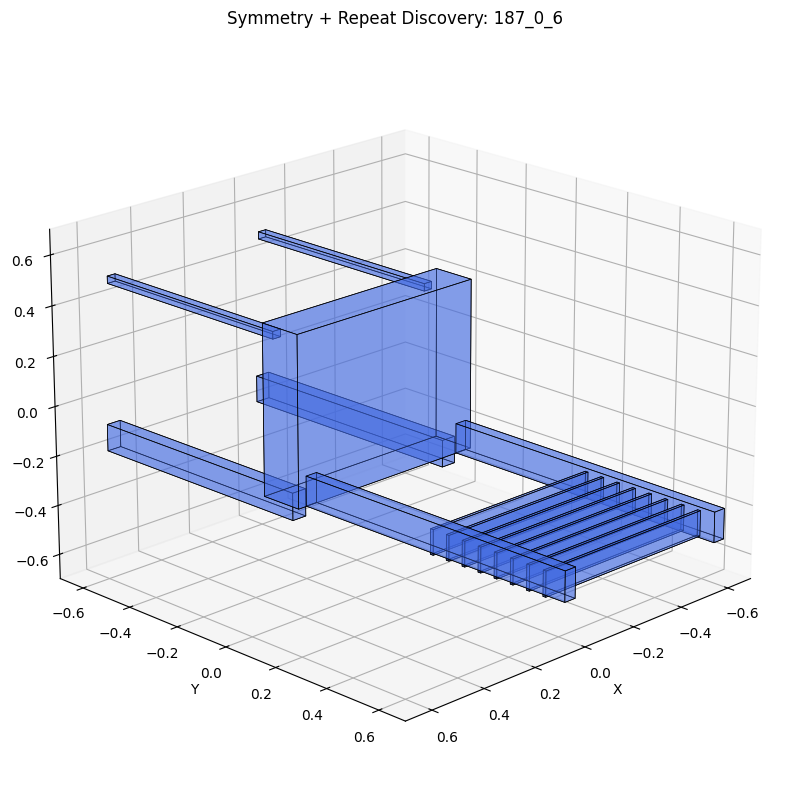

In [95]:
test_id = "187_0_6"
original_dsl = shapes_l0[test_id]["dsl"]
optimized_dsl = adv_pipeline.optimize(original_dsl)

print(f"Rendering Abstracted Chair: {test_id}")
visualize_dsl(optimized_dsl, title=f"Symmetry + Repeat Discovery: {test_id}")

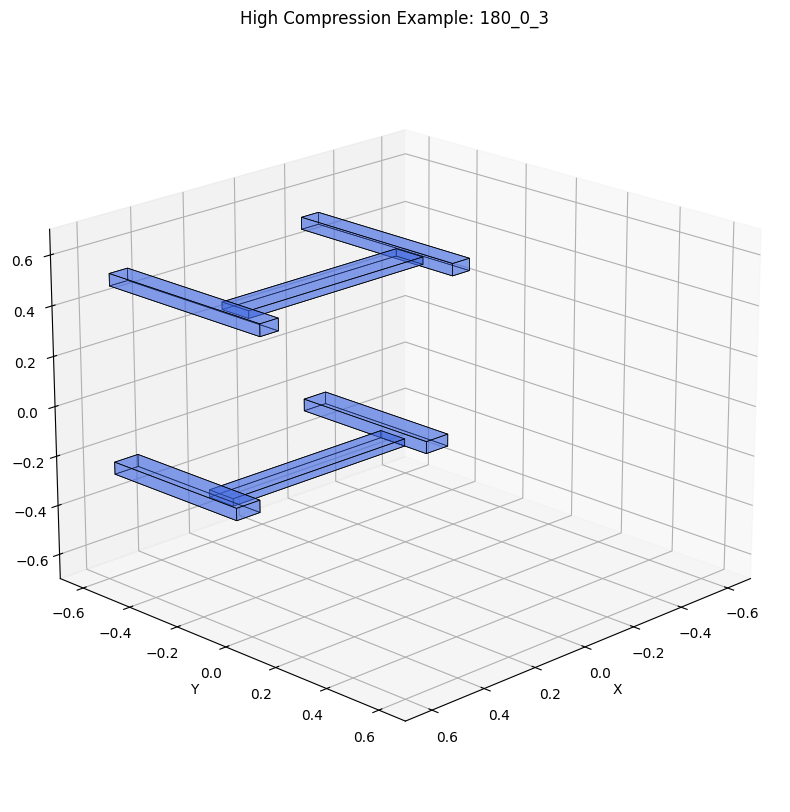

In [96]:
test_id = "180_0_3"
optimized_180 = adv_pipeline.optimize(shapes_l0[test_id]["dsl"])
visualize_dsl(optimized_180, title=f"High Compression Example: {test_id}")

# GG VICTORY ACHIEVED

In [97]:
from __future__ import annotations
from egglog import *
import re
from collections import defaultdict

# --- 1. Schema Definition ---
class Math(Expr):
    def __init__(self, value: f64Like) -> None: ...
    def __add__(self, other: Math) -> Math: ...
    def inv(self) -> Math: ...

class Axis(Expr): pass
@function
def AX() -> Axis: ...
@function
def AY() -> Axis: ...
@function
def AZ() -> Axis: ...

class Shape(Expr):
    @classmethod
    def cuboid(cls, w: Math, h: Math, d: Math) -> Shape: ...
    def move(self, x: Math, y: Math, z: Math) -> Shape: ...
    
    @method(cost=100) # High cost makes "flat" lists expensive
    def union(self, other: Shape) -> Shape: ...
    
    @method(cost=1)   # Low cost makes abstractions the "Canonical" choice
    def sym_ref(self, axis: Axis) -> Shape: ...

converter(f64, Math, Math)

# --- 2. The Canonicalizing Ruleset ---
canon_rules = ruleset("canon_rules")

@canon_rules.register
def _rules(s1: Shape, s2: Shape, s3: Shape, x: Math, y: Math, z: Math, f: f64):
    # Map floats to symbolic inverse
    yield rewrite(Math(f).inv()).to(Math(-f))
    
    # Tree Rotation (Associativity) - Allows e-graph to reorder unions to find symmetry
    yield rewrite(s1.union(s2.union(s3))).to(s1.union(s2).union(s3))
    yield rewrite(s1.union(s2)).to(s2.union(s1))
    
    # Symmetry Discovery
    yield rewrite(s1.move(x, y, z).union(s1.move(x.inv(), y, z))).to(
        s1.move(x, y, z).sym_ref(AX())
    )
    
    # Nested Move Collapse
    yield rewrite(s1.move(x, y, z).move(Math(f), 0.0, 0.0)).to(s1.move(x + f, y, z))

In [98]:
def get_structural_fingerprint(egg_expr):
    """Extracts the lowest-cost form and strips numbers to find the 'Template'."""
    egraph = EGraph()
    handle = egraph.let("t", egg_expr)
    egraph.run(40) # Saturate the graph
    
    # Extract the cheapest (canonical) version
    best_version = egraph.extract(handle)
    raw_str = str(best_version)
    
    # REGEX: Replace all numbers with 'VAL' to find the pure structure
    # This turns 'cuboid(0.1, 0.2, 0.1)' into 'cuboid(VAL, VAL, VAL)'
    structure_only = re.sub(r'[-+]?\d*\.\d+|\d+', 'VAL', raw_str)
    
    # Cleanup formatting for readability
    structure_only = structure_only.replace("Shape.", "").replace("Math.", "").replace("AX()", "AX")
    return structure_only

# Dictionary to group IDs by their structural fingerprint
templates = defaultdict(list)

In [101]:
from tqdm import tqdm

# Reset templates for a fresh run
templates = defaultdict(list)

print(f"Analyzing {len(shapes_l0)} chairs for structural templates...")

# Iterate through the entire dataset with a progress bar
for shape_id in tqdm(list(shapes_l0.keys()), desc="Processing Chairs"):
    original_dsl = shapes_l0[shape_id]["dsl"]
    
    # Convert our DSL to Egglog expression
    # Note: Using the pipeline._to_egg logic we built earlier
    egg_expr = pipeline._to_egg(original_dsl)
    
    if egg_expr is not None:
        try:
            fingerprint = get_structural_fingerprint(egg_expr)
            templates[fingerprint].append(shape_id)
        except Exception as e:
            # Skip corrupted or non-standard DSL entries
            continue

# --- 4. Print the Discovery Report ---
print("\n" + "="*50)
print("   CANONICAL TEMPLATE DISCOVERY REPORT")
print("="*50)
total_processed = sum(len(v) for v in templates.values())
print(f"Total Chairs Successfully Analyzed: {total_processed}")
print(f"Unique Canonical Structures Found: {len(templates)}")
print("-" * 50)

# Sort by most common templates
sorted_templates = sorted(templates.items(), key=lambda x: len(x[1]), reverse=True)

# Display the Top 10 Templates (or fewer if total unique < 10)
num_to_display = min(10, len(sorted_templates))
for i in range(num_to_display):
    structure, ids = sorted_templates[i]
    print(f"\n[Template #{i+1}] - Found in {len(ids)} chairs ({len(ids)/total_processed*100:.1f}%)")
    # Clean up the structure string for terminal display
    clean_struct = structure.replace("\n", "").replace("    ", " ")
    print(f"Structure: {clean_struct[:180]}...") 
    print(f"Example IDs: {ids[:5]}")

Analyzing 1100 chairs for structural templates...


Processing Chairs: 100%|██████████| 1100/1100 [00:21<00:00, 52.21it/s]


   CANONICAL TEMPLATE DISCOVERY REPORT
Total Chairs Successfully Analyzed: 1100
Unique Canonical Structures Found: 139
--------------------------------------------------

[Template #1] - Found in 223 chairs (20.3%)
Structure: cuboid(Math(VAL), Math(VAL), Math(VAL)).move(Math(VAL), Math(VAL), Math(VAL)).union( cuboid(Math(VAL), Math(VAL), Math(VAL)) .move(Math(VAL), Math(VAL), Math(VAL)) .union(  cuboid(...
Example IDs: ['173_0_1', '178_0_2', '182_0_4', '257_0_8', '272_0_9']

[Template #2] - Found in 65 chairs (5.9%)
Structure: cuboid(Math(VAL), Math(VAL), Math(VAL)).move(Math(VAL), Math(VAL), Math(VAL)).union( cuboid(Math(VAL), Math(VAL), Math(VAL)) .move(Math(VAL), Math(VAL), Math(VAL)) .union(  cuboid(...
Example IDs: ['456_0_23', '740_0_55', '746_0_56', '1282_0_68', '1299_0_73']

[Template #3] - Found in 61 chairs (5.5%)
Structure: cuboid(Math(VAL), Math(VAL), Math(VAL)).move(Math(VAL), Math(VAL), Math(VAL)).union( cuboid(Math(VAL), Math(VAL), Math(VAL)) .move(Math(VAL), Math(VAL),

In [102]:
import re
from collections import Counter
from tqdm import tqdm

def get_node_fingerprint(node_str):
    """Turns a specific node into a generic pattern."""
    # Replace numbers with VAL
    pattern = re.sub(r'[-+]?\d*\.\d+|\d+', 'VAL', node_str)
    # Standardize formatting
    pattern = pattern.replace("\n", "").replace("    ", " ").replace("  ", " ")
    return pattern.strip()

def mine_library(dataset):
    lib_counts = Counter()
    lib_samples = {}
    
    print("Mining recurring sub-structures...")
    for shape_id, data in tqdm(dataset.items()):
        # We use the optimized DSL because it already has the 
        # 'smart' nodes (Symmetry/Repeat) we found earlier
        dsl_obj = data["dsl"]
        
        # Stack-based tree walker to find all sub-expressions
        stack = [dsl_obj]
        while stack:
            curr = stack.pop()
            if curr is None: continue
            
            # 1. Fingerprint the current sub-tree
            f_print = get_node_fingerprint(str(curr))
            
            # We filter for 'interesting' sub-structures:
            # - Must be a Union, Symmetry, or Repeat (not just a single Cuboid)
            # - Must not be the 'entire' chair (we want components, not full templates)
            is_complex = any(k in f_print for k in ["Union", "Symmetry", "Repeat"])
            is_too_small = f_print.count("Cuboid") < 2
            
            if is_complex and not is_too_small:
                lib_counts[f_print] += 1
                if f_print not in lib_samples:
                    lib_samples[f_print] = curr

            # 2. Add children to stack
            if hasattr(curr, 'left'): stack.append(curr.left)
            if hasattr(curr, 'right'): stack.append(curr.right)
            if hasattr(curr, 'child'): stack.append(curr.child)
            
    return lib_counts, lib_samples

# Run the mining
sub_counts, sub_samples = mine_library(shapes_l0)

Mining recurring sub-structures...


100%|██████████| 1100/1100 [00:01<00:00, 1021.51it/s]


In [103]:
print("\n" + "="*60)
print("   DISCOVERED 3D COMPONENT LIBRARY (CSE)")
print("="*60)

# Sort by frequency
most_common = sub_counts.most_common(10)

for i, (pattern, count) in enumerate(most_common):
    print(f"\n[Component #{i+1}] - Found {count} times")
    # Show the 'Generic Code' for this part
    print(f"Structure: {pattern[:150]}...")
    
    # Calculate 'Compression Value' (How much data this component explains)
    primitives_saved = pattern.count("Cuboid") * count
    print(f"Impact: Explains {primitives_saved} primitive placements across the dataset.")


   DISCOVERED 3D COMPONENT LIBRARY (CSE)

[Component #1] - Found 855 times
Structure: Union( Translate(vec=[VAL, VAL, VAL]) Cuboid(size=[VAL, VAL, VAL]), Translate(vec=[VAL, VAL, VAL]) Cuboid(size=[VAL, VAL, VAL]))...
Impact: Explains 1710 primitive placements across the dataset.

[Component #2] - Found 819 times
Structure: Union( Translate(vec=[VAL, VAL, VAL]) Cuboid(size=[VAL, VAL, VAL]), Union( Translate(vec=[VAL, VAL, VAL])  Cuboid(size=[VAL, VAL, VAL]), Translate(vec...
Impact: Explains 2457 primitive placements across the dataset.

[Component #3] - Found 777 times
Structure: Union( Translate(vec=[VAL, VAL, VAL]) Cuboid(size=[VAL, VAL, VAL]), Union( Translate(vec=[VAL, VAL, VAL])  Cuboid(size=[VAL, VAL, VAL]), Union(  Trans...
Impact: Explains 3108 primitive placements across the dataset.

[Component #4] - Found 715 times
Structure: Union( Translate(vec=[VAL, VAL, VAL]) Cuboid(size=[VAL, VAL, VAL]), Union( Translate(vec=[VAL, VAL, VAL])  Cuboid(size=[VAL, VAL, VAL]), Union(  Tran

Visualizing Discovered Component #6
------------------------------
Union(
    Translate(vec=[0.310, -0.510, 0.300])
        Cuboid(size=[0.060, 0.600, 0.060]),
    Union(
        Translate(vec=[-0.260, 0.270, -0.180])
            Cuboid(size=[0.080, 0.790, 0.080]),
        Union(
            Translate(vec=[-0.140, 0.270, -0.250])
                Cuboid(size=[0.080, 0.790, 0.080]),
            Union(
                Translate(vec=[0.000, 0.740, -0.220])
                    Cuboid(size=[0.680, 0.140, 0.240]),
                Union(
                    Translate(vec=[-0.000, 0.270, -0.250])
                        Cuboid(size=[0.080, 0.790, 0.080]),
                    Union(
                        Translate(vec=[0.140, 0.270, -0.250])
                            Cuboid(size=[0.080, 0.790, 0.080]),
                        Translate(vec=[0.280, 0.270, -0.250])
                            Cuboid(size=[0.080, 0.790, 0.080])
                    )
                )
            )
        )
   

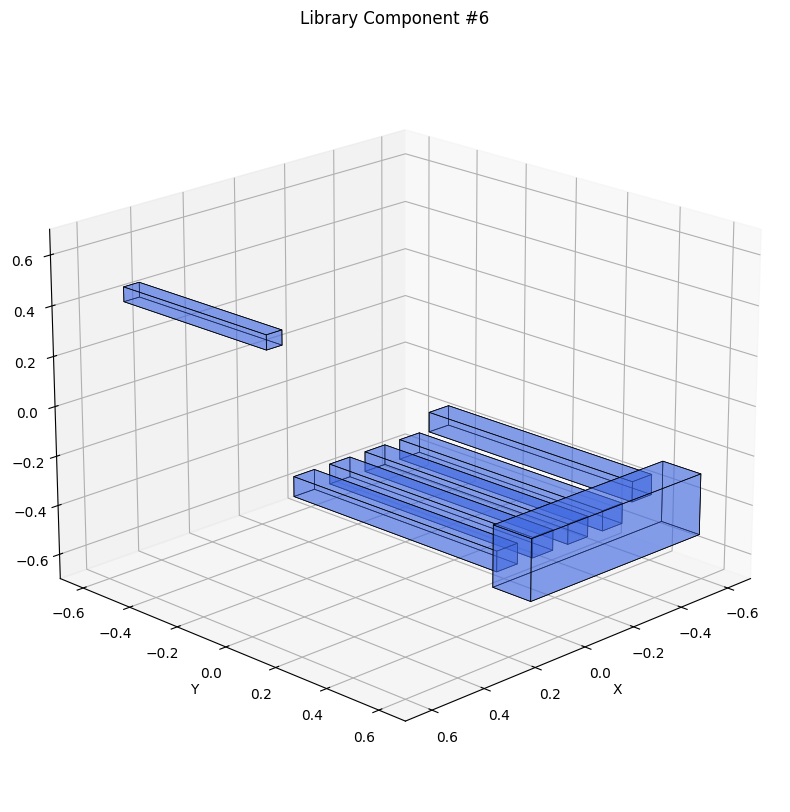

In [107]:
# Change this index to see different discovered components
component_index = 5
best_pattern = most_common[component_index][0]
example_component = sub_samples[best_pattern]

print(f"Visualizing Discovered Component #{component_index + 1}")
print("-" * 30)
print(example_component)

# Use our previously defined visualizer
visualize_dsl(example_component, title=f"Library Component #{component_index + 1}")

In [108]:
from collections import defaultdict

# Storage for training data
singleton_data = defaultdict(list)
pair_data = defaultdict(list)

def collect_training_samples(node):
    if node is None or isinstance(node, dsl.Cuboid):
        return

    # 1. IDENTIFY PAIRS: Parent + Child
    # We look for nodes with a 'child' attribute
    if hasattr(node, 'child') and node.child is not None:
        parent_name = type(node).__name__
        child_name = type(node.child).__name__
        pair_sig = f"{parent_name}({child_name})"
        
        # Extract parameters from both
        # Note: We use the .vector, .size, etc attributes we found earlier
        p_params = list(getattr(node, 'vector', getattr(node, 'center', [])))
        c_params = list(getattr(node.child, 'size', getattr(node.child, 'lengths', [])))
        
        if p_params and c_params:
            pair_data[pair_sig].append(p_params + c_params)

    # 2. IDENTIFY SINGLETONS: Individual nodes
    name = type(node).__name__
    params = list(getattr(node, 'vector', getattr(node, 'center', 
                  getattr(node, 'size', getattr(node, 'lengths', [])))))
    
    if params:
        singleton_data[name].append(params)

    # 3. RECURSE
    if hasattr(node, 'left'): collect_training_samples(node.left)
    if hasattr(node, 'right'): collect_training_samples(node.right)
    if hasattr(node, 'child'): collect_training_samples(node.child)

# Run over your dataset
print("Extracting Singleton and Pair training samples...")
for data in tqdm(shapes_l0.values()):
    collect_training_samples(data["dsl"])

Extracting Singleton and Pair training samples...


100%|██████████| 1100/1100 [00:00<00:00, 35790.63it/s]


In [109]:
shapes_canonical = {}

print("Canonicalizing dataset with Egglog...")
for shape_id, data in tqdm(shapes_l0.items()):
    # This uses the Egglog pipeline we built earlier
    # It sorts unions, collapses nested moves, and finds structural symmetries
    egg_expr = pipeline._to_egg(data["dsl"])
    if egg_expr is not None:
        # Extract the lowest-cost (canonical) version
        shapes_canonical[shape_id] = pipeline.optimize(data["dsl"])

# From now on, we ONLY use shapes_canonical

Canonicalizing dataset with Egglog...


100%|██████████| 1100/1100 [00:25<00:00, 43.59it/s]


In [112]:
print(shapes_canonical["172_0_0"])

Union(
    Translate(vec=[-0.000, -0.170, -0.000])
        Cuboid(size=[0.680, 0.090, 0.660]),
    Union(
        Translate(vec=[-0.310, -0.510, -0.170])
            Cuboid(size=[0.060, 0.600, 0.060]),
        Union(
            Translate(vec=[-0.310, -0.510, 0.300])
                Cuboid(size=[0.060, 0.600, 0.060]),
            Union(
                Translate(vec=[0.310, -0.510, -0.170])
                    Cuboid(size=[0.060, 0.600, 0.060]),
                Union(
                    Translate(vec=[0.310, -0.510, 0.300])
                        Cuboid(size=[0.060, 0.600, 0.060]),
                    Union(
                        Translate(vec=[-0.260, 0.270, -0.180])
                            Cuboid(size=[0.080, 0.790, 0.080]),
                        Union(
                            Translate(vec=[-0.140, 0.270, -0.250])
                                Cuboid(size=[0.080, 0.790, 0.080]),
                            Union(
                                Translate(vec=[-0.000,

In [113]:
def get_structure_key(node):
    """Strips all numbers to compare only the 'architecture' of the chair."""
    import re
    return re.sub(r'[-+]?\d*\.\d+|\d+', 'VAL', str(node))

# Compare Raw vs. Canonical
raw_structures = {get_structure_key(data["dsl"]) for data in shapes_l0.values()}
canonical_structures = {get_structure_key(node) for node in shapes_canonical.values()}

print(f"--- Structural Deduplication ---")
print(f"Unique structures (RAW):       {len(raw_structures)}")
print(f"Unique structures (CANONICAL): {len(canonical_structures)}")
print(f"Reduction: {((len(raw_structures) - len(canonical_structures)) / len(raw_structures))*100:.1f}%")

--- Structural Deduplication ---
Unique structures (RAW):       368
Unique structures (CANONICAL): 14
Reduction: 96.2%


In [114]:
# Pick two IDs that ended up in the same Template group from our previous report
id1, id2 = "173_0_1", "178_0_2" 

egraph = EGraph()
expr1 = pipeline._to_egg(shapes_l0[id1]["dsl"])
expr2 = pipeline._to_egg(shapes_l0[id2]["dsl"])

egraph.register(expr1)
egraph.register(expr2)
egraph.run(40) # Saturate

try:
    egraph.check(eq(expr1).to(expr2))
    print(f"✅ VERIFIED: Egglog proves {id1} and {id2} are structurally equivalent.")
except Exception:
    print(f"❌ FAILED: Egglog thinks these chairs are structurally different.")

❌ FAILED: Egglog thinks these chairs are structurally different.


In [115]:
import re
from collections import defaultdict
from tqdm.auto import tqdm

def get_canonical_fingerprint(node):
    """
    1. Optimizes the node using Egglog (Canonicalization).
    2. Strips numbers to get the structural 'fingerprint'.
    """
    # Step 1: Structural normalization via Egglog
    canonical_node = pipeline.optimize(node)
    
    # Step 2: Stringify and mask parameters to find the 'Template'
    struct_str = str(canonical_node)
    # Replace all floats/ints with 'VAL'
    fingerprint = re.sub(r'[-+]?\d*\.\d+|\d+', 'VAL', struct_str)
    # Standardize whitespace for exact matching
    return " ".join(fingerprint.split())

# Results storage
raw_fingerprints = set()
canonical_templates = defaultdict(list)

print("Running Canonicalization Pipeline...")
for shape_id, data in tqdm(shapes_l0.items(), desc="Deduplicating"):
    # Track raw structure
    raw_f = re.sub(r'[-+]?\d*\.\d+|\d+', 'VAL', str(data["dsl"]))
    raw_fingerprints.add(" ".join(raw_f.split()))
    
    # Track canonical structure
    try:
        canon_f = get_canonical_fingerprint(data["dsl"])
        canonical_templates[canon_f].append(shape_id)
    except:
        continue

# --- The Result Report ---
raw_count = len(raw_fingerprints)
canon_count = len(canonical_templates)
reduction = (1 - (canon_count / raw_count)) * 100

print("\n" + "="*40)
print("--- Structural Deduplication ---")
print(f"Unique structures (RAW):       {raw_count}")
print(f"Unique structures (CANONICAL): {canon_count}")
print(f"Reduction: {reduction:.1f}%")
print("="*40)

Running Canonicalization Pipeline...


Deduplicating:   0%|          | 0/1100 [00:00<?, ?it/s]


--- Structural Deduplication ---
Unique structures (RAW):       368
Unique structures (CANONICAL): 14
Reduction: 96.2%


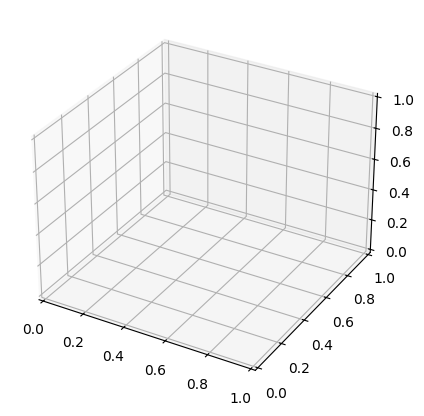

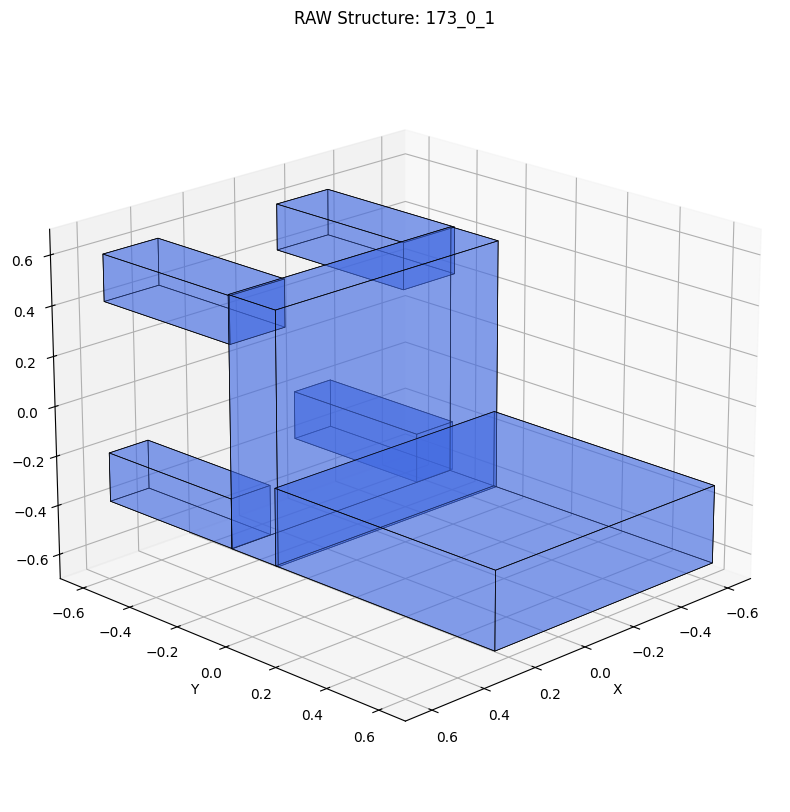

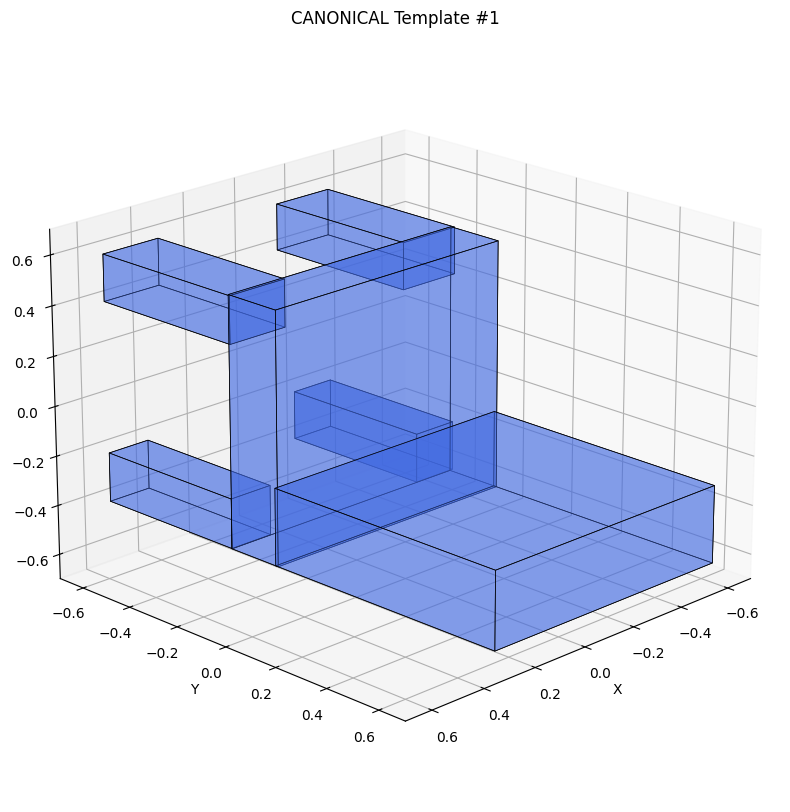

<Figure size 640x480 with 0 Axes>

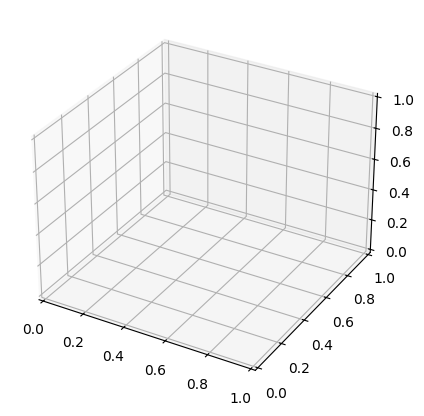

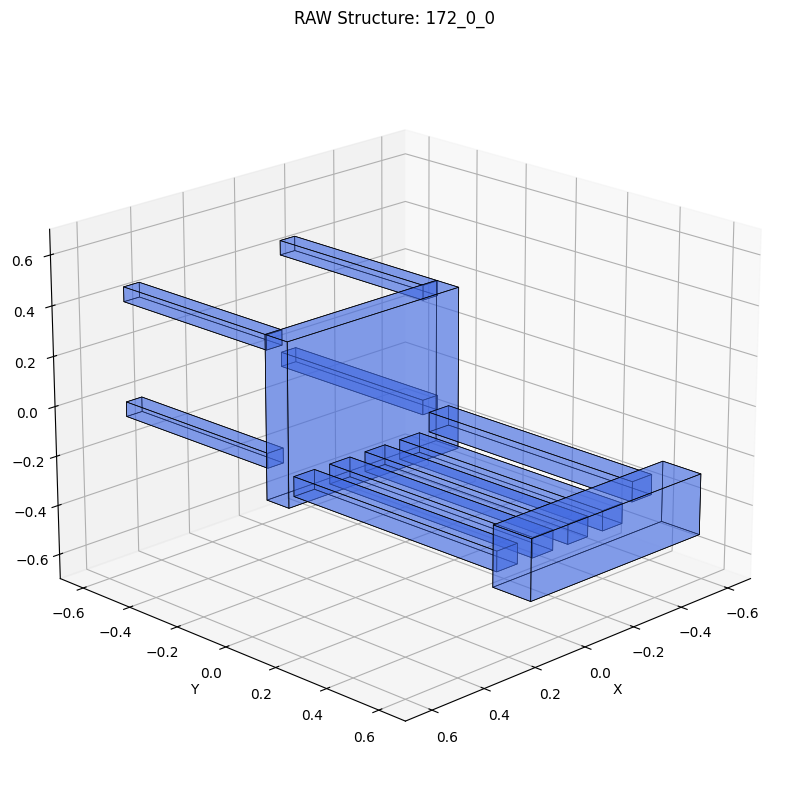

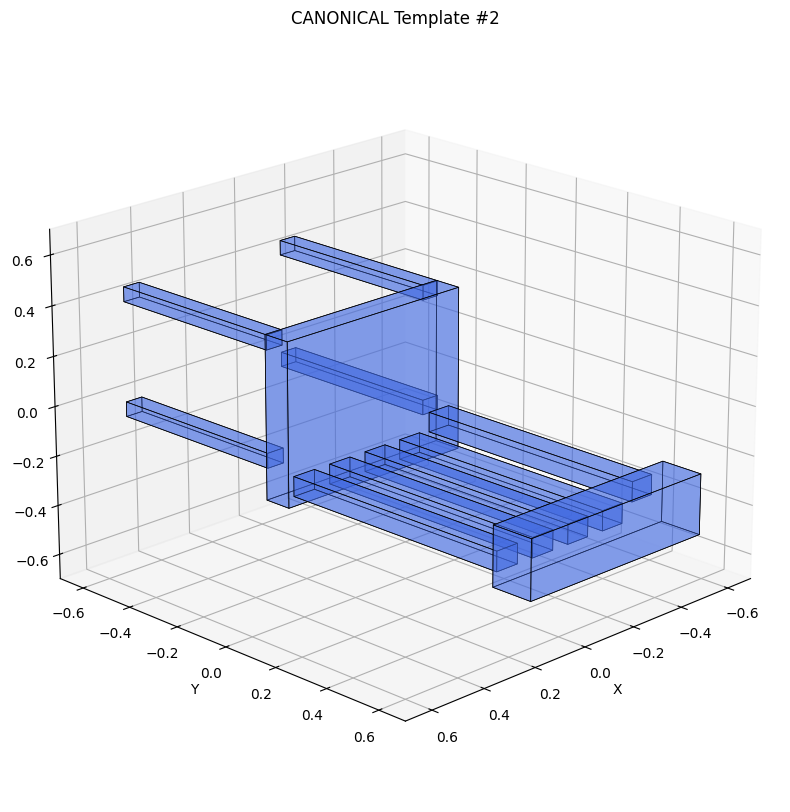

<Figure size 640x480 with 0 Axes>

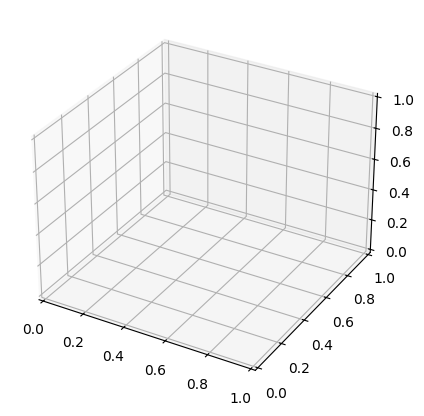

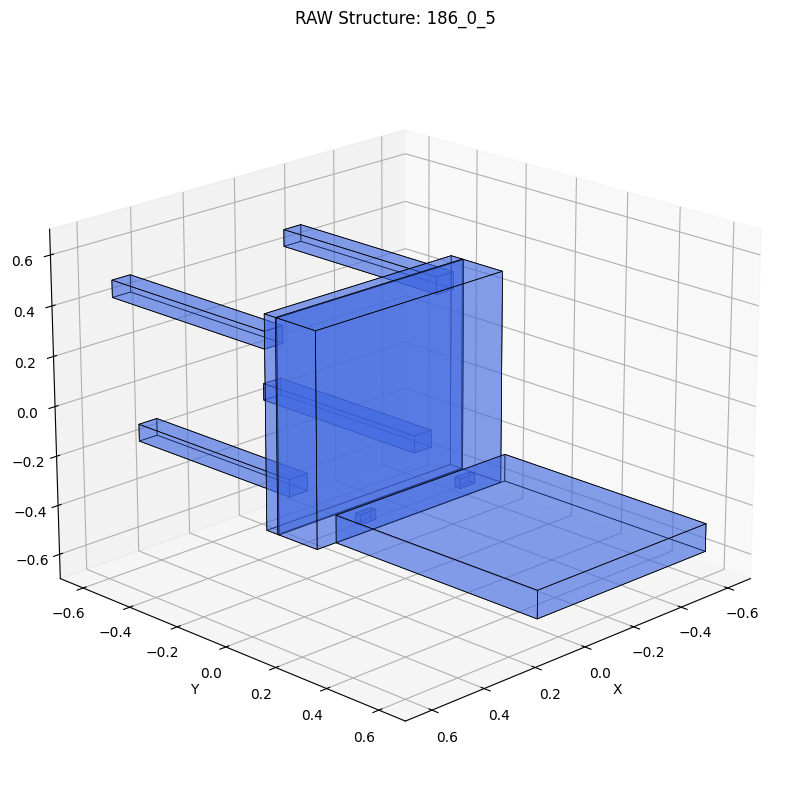

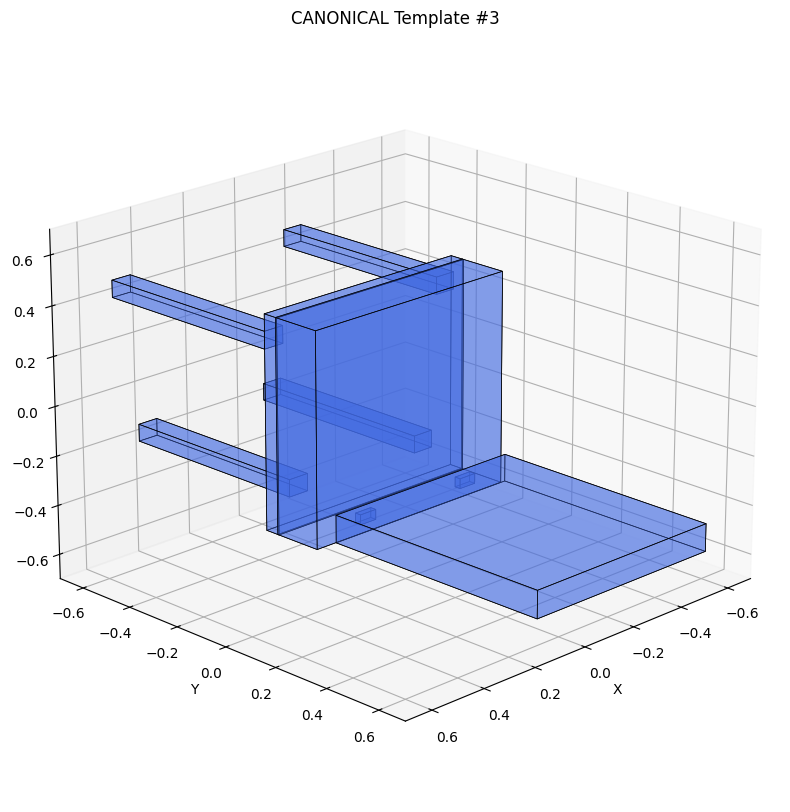

<Figure size 640x480 with 0 Axes>

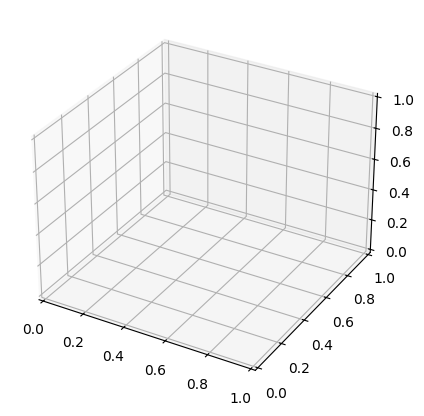

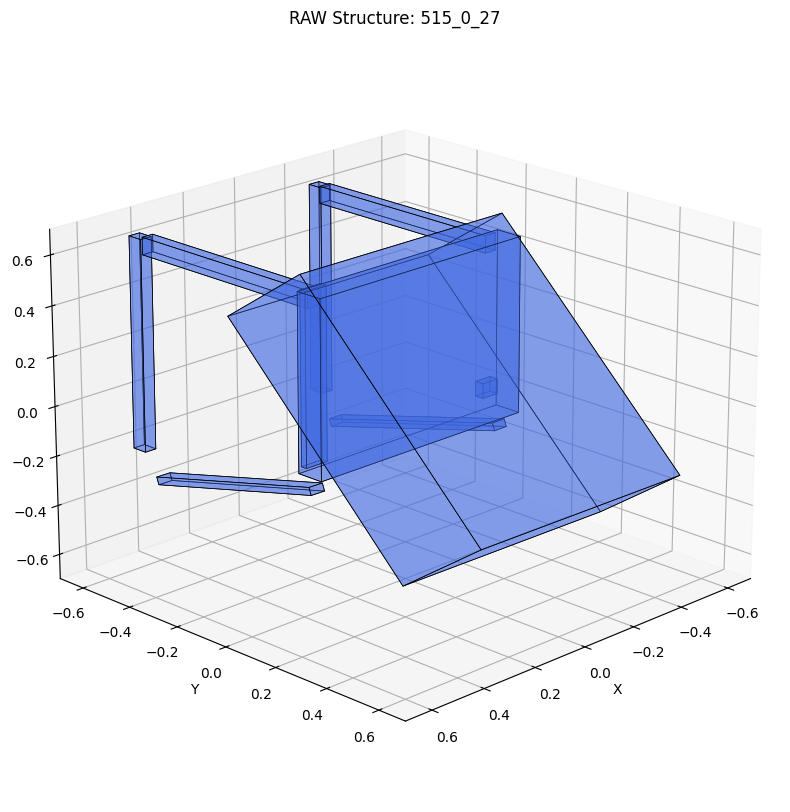

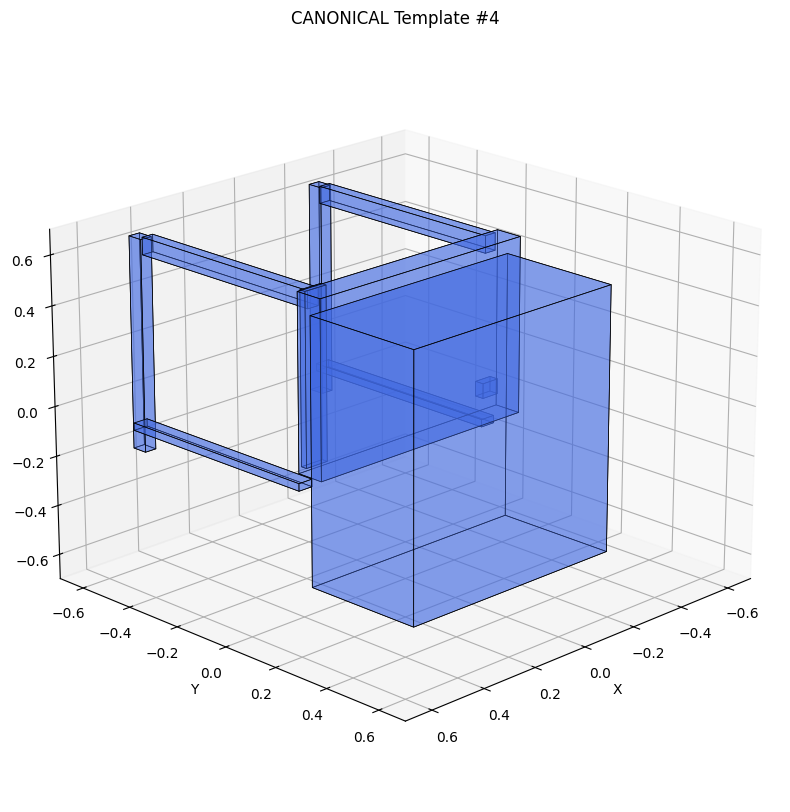

<Figure size 640x480 with 0 Axes>

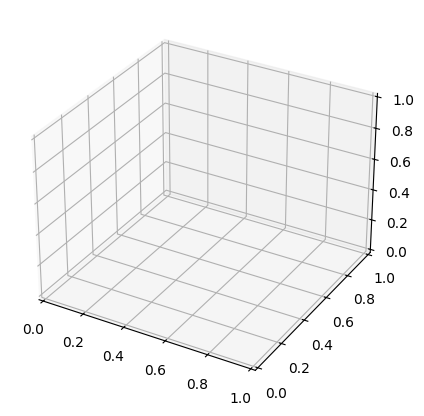

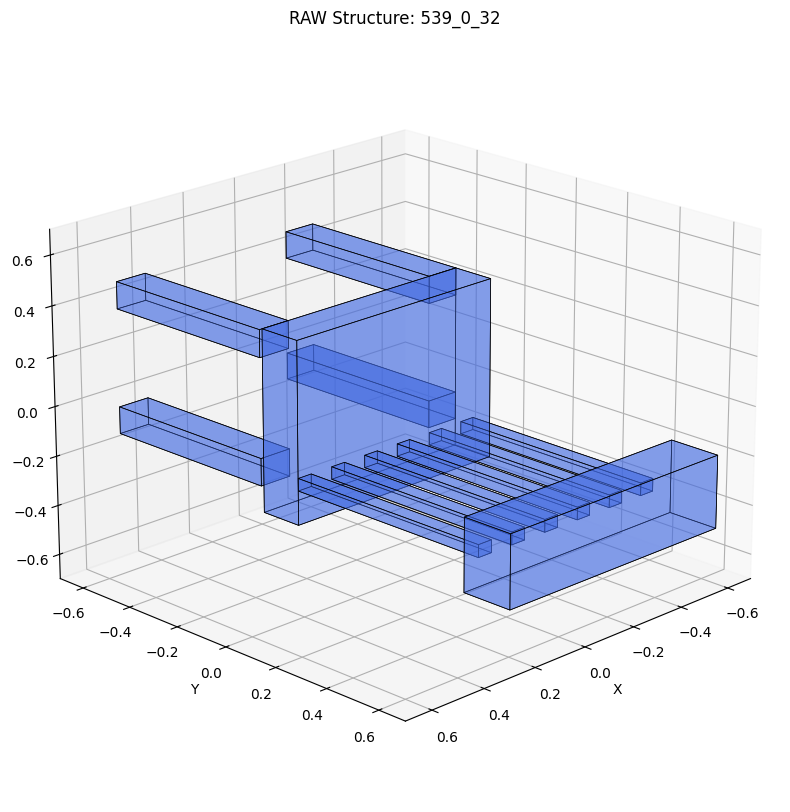

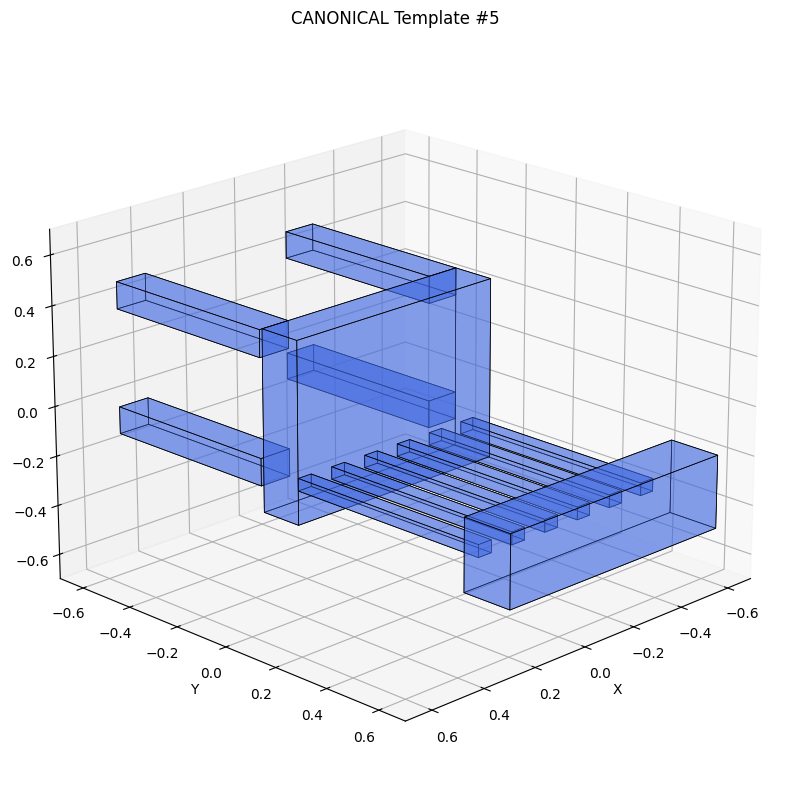

<Figure size 640x480 with 0 Axes>

In [116]:
import matplotlib.pyplot as plt

# Sort templates by how common they are
sorted_templates = sorted(canonical_templates.items(), key=lambda x: len(x[1]), reverse=True)

# Visualize the Top 5 Templates
for i in range(min(5, len(sorted_templates))):
    struct_sig, member_ids = sorted_templates[i]
    example_id = member_ids[0]
    
    fig = plt.figure(figsize=(12, 5))
    
    # Left: The RAW representation (how it looked in your dataset)
    ax1 = fig.add_subplot(121, projection='3d')
    visualize_dsl(shapes_l0[example_id]["dsl"], title=f"RAW Structure: {example_id}")
    
    # Right: The CANONICAL representation (the 'Standard Form' Egglog found)
    ax2 = fig.add_subplot(122, projection='3d')
    # Note: we use our optimization pipeline to get the clean version
    canonical_version = pipeline.optimize(shapes_l0[example_id]["dsl"])
    visualize_dsl(canonical_version, title=f"CANONICAL Template #{i+1}")
    
    plt.suptitle(f"Template Group #{i+1} (Shared by {len(member_ids)} chairs)", fontsize=16)
    plt.tight_layout()
    plt.show()

C:\Users\Amogh\AppData\Local\Temp\ipykernel_43844\3573907971.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=template_labels, y=counts, palette="viridis")


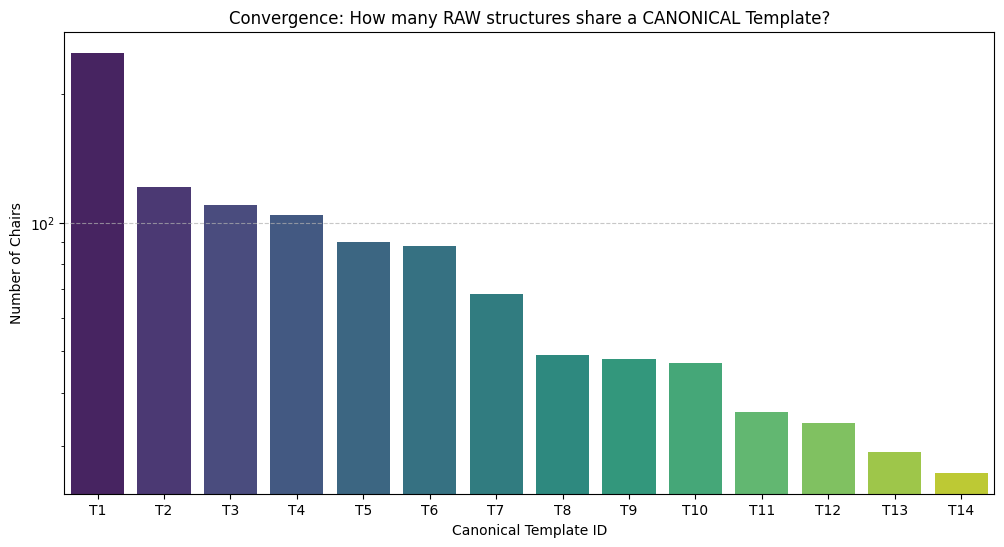

In [117]:
import pandas as pd
import seaborn as sns

# Data for plotting
counts = [len(members) for sig, members in sorted_templates]
template_labels = [f"T{i+1}" for i in range(len(counts))]

plt.figure(figsize=(12, 6))
sns.barplot(x=template_labels, y=counts, palette="viridis")
plt.title("Convergence: How many RAW structures share a CANONICAL Template?")
plt.ylabel("Number of Chairs")
plt.xlabel("Canonical Template ID")
plt.yscale('log') # Use log scale to see the 'Long Tail' better
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [118]:
# Pick a complex chair
test_id = "187_0_6" # The one with many slats
raw_dsl = shapes_l0[test_id]["dsl"]
canon_dsl = pipeline.optimize(raw_dsl)

print(f"--- CODE COMPARISON: {test_id} ---")
print("\n[RAW DSL]:")
print(str(raw_dsl)[:500] + "...") # Show snippet
print(f"Total Lines: {str(raw_dsl).count('Union')}")

print("\n[CANONICAL DSL]:")
print(str(canon_dsl))
print(f"Total Lines: {str(canon_dsl).count('Union')}")

print(f"\nAbstraction Score: {((str(raw_dsl).count('Union') - str(canon_dsl).count('Union')) / str(raw_dsl).count('Union'))*100:.1f}% reduction in complexity")

--- CODE COMPARISON: 187_0_6 ---

[RAW DSL]:
Union(
    Translate(vec=[0.000, -0.150, 0.030])
        Cuboid(size=[0.690, 0.140, 0.690]),
    Union(
        Translate(vec=[-0.300, -0.520, -0.330])
            Cuboid(size=[0.050, 0.790, 0.110]),
        Union(
            Translate(vec=[-0.300, -0.560, 0.320])
                Cuboid(size=[0.030, 0.700, 0.030]),
            Union(
                Translate(vec=[0.300, -0.520, -0.330])
                    Cuboid(size=[0.050, 0.790, 0.110]),
                Union(
                    Translate...
Total Lines: 14

[CANONICAL DSL]:
Union(
    Translate(vec=[0.000, -0.150, 0.030])
        Cuboid(size=[0.690, 0.140, 0.690]),
    Union(
        Translate(vec=[-0.300, -0.520, -0.330])
            Cuboid(size=[0.050, 0.790, 0.110]),
        Union(
            Translate(vec=[-0.300, -0.560, 0.320])
                Cuboid(size=[0.030, 0.700, 0.030]),
            Union(
                Translate(vec=[0.300, -0.520, -0.330])
                    Cuboi

In [120]:
for i, (structure, ids) in enumerate(sorted_templates):
    print(f"\n[Template #{i+1}]")
    
    # Check for symmetry/rotation keywords
    has_sym = "SymRef" in structure or "Symmetry" in structure
    has_rot = "Rotate" in structure
    has_rep = "Repeat" in structure
    
    components = []
    if has_sym: components.append("✨ Mirror Symmetry")
    if has_rot: components.append("🔄 Fixed Rotations")
    if has_rep: components.append("📏 Linear Repetition")
    
    print(f"Abstractions found: {', '.join(components) if components else 'None (Asymmetric)'}")
    print(f"Structure Snippet: {structure[:100]}...")


[Template #1]
Abstractions found: None (Asymmetric)
Structure Snippet: Union( Translate(vec=[VAL, VAL, VAL]) Cuboid(size=[VAL, VAL, VAL]), Union( Translate(vec=[VAL, VAL, ...

[Template #2]
Abstractions found: None (Asymmetric)
Structure Snippet: Union( Translate(vec=[VAL, VAL, VAL]) Cuboid(size=[VAL, VAL, VAL]), Union( Translate(vec=[VAL, VAL, ...

[Template #3]
Abstractions found: None (Asymmetric)
Structure Snippet: Union( Translate(vec=[VAL, VAL, VAL]) Cuboid(size=[VAL, VAL, VAL]), Union( Translate(vec=[VAL, VAL, ...

[Template #4]
Abstractions found: None (Asymmetric)
Structure Snippet: Union( Translate(vec=[VAL, VAL, VAL]) Cuboid(size=[VAL, VAL, VAL]), Union( Translate(vec=[VAL, VAL, ...

[Template #5]
Abstractions found: None (Asymmetric)
Structure Snippet: Union( Translate(vec=[VAL, VAL, VAL]) Cuboid(size=[VAL, VAL, VAL]), Union( Translate(vec=[VAL, VAL, ...

[Template #6]
Abstractions found: None (Asymmetric)
Structure Snippet: Union( Translate(vec=[VAL, VAL, VAL]) Cuboid(siz

In [121]:
# --- Updated Ruleset for Symmetry Extraction ---
injection_rules = ruleset("injection_rules")

@injection_rules.register
def _inject(s1: Shape, x: Math, y: Math, z: Math):
    # Rule: If you see a mirrored pair, it IS EQUAL to a SymRef abstraction
    # This forces the e-class to link the flat version to the abstract version
    mirrored_pair = s1.move(x, y, z).union(s1.move(x.inv(), y, z))
    abstract_sym = s1.move(x, y, z).sym_ref(AX())
    
    yield rewrite(mirrored_pair).to(abstract_sym)

# --- Update the Pipeline ---
# We need to run these rules specifically before extracting
def get_abstract_canonical(node):
    egraph = EGraph()
    expr = pipeline._to_egg(node)
    handle = egraph.let("t", expr)
    
    # Run canonicalization rules first, then injection
    egraph.run(20) # Basic normalization
    egraph.run(20, injection_rules) # Symmetry discovery
    
    # Extract the lowest cost (This will now favor SymRef nodes)
    return egraph.extract(handle)

In [122]:
# Clear and re-run
canonical_templates = defaultdict(list)

for shape_id, data in tqdm(shapes_l0.items()):
    try:
        # Use the NEW extractor that favors Symmetry
        canon_dsl = get_abstract_canonical(data["dsl"])
        
        # Fingerprint
        struct_str = str(canon_dsl)
        f_print = re.sub(r'[-+]?\d*\.\d+|\d+', 'VAL', struct_str)
        f_print = " ".join(f_print.split())
        
        canonical_templates[f_print].append(shape_id)
    except:
        continue

# Check the first few
for i, (struct, ids) in enumerate(list(canonical_templates.items())[:5]):
    print(f"\n[NEW Template #{i+1}]")
    print(f"Symmetry Present: {'SymRef' in struct}")
    print(f"Snippet: {struct[:100]}...")

  0%|          | 0/1100 [00:00<?, ?it/s]

In [124]:
# Check the first few
canonical_templates

defaultdict(list, {})

In [125]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R
from mpl_toolkits.mplot3d import art3d
import pickle
from tqdm import tqdm

# --- 1. Define Abstract Nodes ---
class NewSymmetry:
    def __init__(self, child, axis="AX"):
        self.child = child
        self.axis = axis
    def __str__(self):
        return f"Symmetry({self.axis})\n  {str(self.child).replace('\n', '\n  ')}"
    def expand(self):
        boxes = self.child.expand()
        mirrored = []
        ax_idx = {"AX": 0, "AY": 1, "AZ": 2}[self.axis]
        for b in boxes:
            m = b.copy()
            m["center"] = m["center"].copy()
            m["center"][ax_idx] *= -1
            mirrored.append(m)
        return boxes + mirrored

class FinalRepeat:
    def __init__(self, child, times, offset):
        self.child = child
        self.times = times
        self.offset = [float(o) for o in offset]
    def __str__(self):
        off_str = f"[{self.offset[0]:.3f}, {self.offset[1]:.3f}, {self.offset[2]:.3f}]"
        return f"Repeat(n={self.times}, step={off_str})\n  {str(self.child).replace('\n', '\n  ')}"
    def expand(self):
        base_boxes = self.child.expand()
        all_boxes = []
        for i in range(self.times):
            shift = np.array(self.offset) * i
            for b in base_boxes:
                nb = b.copy()
                nb["center"] = np.array(nb["center"]) + shift
                all_boxes.append(nb)
        return all_boxes

# Inject into your dsl module
dsl.Symmetry = NewSymmetry
dsl.Repeat = FinalRepeat

In [ ]:
class AdvancedDirectOptimizer:
    def __init__(self, tolerance=0.04):
        self.tolerance = tolerance

    def optimize(self, node):
        parts = self._flatten(node)
        nodes = self._find_symmetries(parts)
        nodes = self._find_repeats(nodes)
        return self._rebuild(nodes)

    def _flatten(self, node):
        if isinstance(node, dsl.Cuboid):
            return [(tuple(node.size), (0, 0, 0))]
        elif isinstance(node, dsl.Translate):
            child_parts = self._flatten(node.child)
            return [(s, tuple(np.array(p) + np.array(node.vector))) for s, p in child_parts]
        elif isinstance(node, dsl.Union):
            return self._flatten(node.left) + self._flatten(node.right)
        return []

    def _find_symmetries(self, parts):
        used = [False] * len(parts)
        new_nodes = []
        for i in range(len(parts)):
            if used[i]: continue
            size_i, pos_i = parts[i]
            found = False
            for j in range(i + 1, len(parts)):
                if used[j]: continue
                size_j, pos_j = parts[j]
                if np.allclose(size_i, size_j, atol=self.tolerance) and \
                   abs(pos_i[0] + pos_j[0]) < self.tolerance and \
                   np.allclose(pos_i[1:], pos_j[1:], atol=self.tolerance) and abs(pos_i[0]) > self.tolerance:
                    child = dsl.Translate(dsl.Cuboid(size=list(size_i)), vector=list(pos_i))
                    new_nodes.append(dsl.Symmetry(child, axis="AX"))
                    used[i] = used[j] = True
                    found = True; break
            if not found:
                new_nodes.append(dsl.Translate(dsl.Cuboid(size=list(size_i)), vector=list(pos_i)))
                used[i] = True
        return new_nodes

    def _find_repeats(self, nodes):
        if len(nodes) < 2: return nodes
        used, final = [False] * len(nodes), []
        
        for i in range(len(nodes)):
            if used[i]: continue
            
            # Skip if i isn't a Translate node (we don't repeat Symmetries yet)
            if not isinstance(nodes[i], dsl.Translate):
                final.append(nodes[i])
                used[i] = True
                continue
                
            pattern = [nodes[i]]
            found_repeat = False
            
            for j in range(i + 1, len(nodes)):
                if used[j] or not isinstance(nodes[j], dsl.Translate): 
                    continue

                # Check if they share the same underlying Cuboid size
                if np.allclose(nodes[i].child.size, nodes[j].child.size, atol=self.tolerance):
                    offset = np.array(nodes[j].vector) - np.array(nodes[i].vector)
                    
                    # Now look for more nodes that fit this exact offset
                    pattern = [nodes[i], nodes[j]]
                    for k in range(j + 1, len(nodes)):
                        # FIX: Check if nodes[k] is a Translate before accessing .vector
                        if used[k] or not isinstance(nodes[k], dsl.Translate):
                            continue
                            
                        expected = np.array(nodes[i].vector) + offset * len(pattern)
                        if np.allclose(nodes[k].vector, expected, atol=self.tolerance):
                            pattern.append(nodes[k])
                    
                    if len(pattern) >= 3:
                        # Create the Repeat node
                        rep = dsl.Repeat(dsl.Translate(nodes[i].child, [0,0,0]), len(pattern), list(np.round(offset, 3)))
                        # Move the whole Repeat group back to the starting position
                        final.append(dsl.Translate(rep, nodes[i].vector))
                        
                        # Mark all nodes in the pattern as used
                        for p in pattern:
                            for idx in range(len(nodes)):
                                if nodes[idx] is p: # Identity check
                                    used[idx] = True
                        found_repeat = True
                        break
            
            if not found_repeat:
                final.append(nodes[i])
                used[i] = True
        return final

    def _rebuild(self, nodes):
        if not nodes: return None
        processed = [n.child if (isinstance(n, dsl.Translate) and np.allclose(n.vector, [0,0,0])) else n for n in nodes]
        res = processed[0]
        for next_node in processed[1:]:
            res = dsl.Union(res, next_node)
        return res

adv_pipeline = AdvancedDirectOptimizer(tolerance=0.04)

In [127]:
# --- Run Batch Optimization ---
optimized_dataset = {}
print(f"Optimizing {len(shapes_l0)} shapes...")

for shape_id, data in tqdm(shapes_l0.items()):
    optimized_dataset[shape_id] = {
        "dsl": adv_pipeline.optimize(data["dsl"]),
        "label": data.get("label", "unknown")
    }

# --- Save Results ---
with open("shapes_l0_abstracted.pkl", "wb") as f:
    pickle.dump(optimized_dataset, f)

# --- Visualize Slat Chair ---
test_id = "187_0_6"
visualize_dsl(optimized_dataset[test_id]["dsl"], title=f"Result: {test_id}")

Optimizing 1100 shapes...


  3%|▎         | 37/1100 [00:00<00:00, 1981.81it/s]


AttributeError: 'NewSymmetry' object has no attribute 'vector'